In [ ]:
# from google.colab import drive
# drive.mount('/content/drive/')

# %cd /content/drive/MyDrive/Colab Notebooks/Kaggle Tubular Playground Series/S4E8 Binary Prediction of Poisonous Mushrooms/

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from sklearn.preprocessing import OrdinalEncoder, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import root_mean_squared_error as rmse
from sklearn.model_selection import KFold
from sklearn.compose import ColumnTransformer 
from xgboost import XGBRegressor
import xgboost as xgb
import eda_util
import optuna

c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
RANDOM_STATE = 1048576
TARGET = 'accident_risk'

# Data Loading

In [3]:
train_csv = pd.read_csv('datasets/train_split.csv', index_col=0)
val_csv = pd.read_csv('datasets/val_split.csv', index_col=0)
test_csv = pd.read_csv('datasets/test_split.csv', index_col=0)

In [4]:
display(train_csv.head())
display(val_csv.head())
display(test_csv.head())

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
id,,,,,,,,,,,,,
313352,rural,2,0.22,45,night,foggy,False,True,evening,True,False,2,0.36
348526,rural,4,0.22,35,night,foggy,True,False,afternoon,True,False,2,0.42
419885,urban,1,0.18,60,dim,rainy,True,False,evening,False,False,0,0.40
37241,rural,2,0.92,25,dim,clear,True,True,afternoon,False,True,1,0.35
85356,urban,4,0.14,25,night,rainy,True,True,evening,True,False,0,0.34


,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
id,,,,,,,,,,,,,
262368,rural,4,0.37,35,daylight,clear,True,False,evening,False,False,1,0.06
341957,rural,4,0.75,60,daylight,clear,False,False,morning,True,True,2,0.48
66336,rural,2,0.66,35,daylight,foggy,True,True,morning,False,True,1,0.32
325259,highway,2,0.90,45,night,clear,True,True,evening,True,True,0,0.45
477777,rural,2,0.28,25,night,rainy,True,True,evening,False,False,2,0.46


,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
id,,,,,,,,,,,,,
73059,highway,4,0.49,70,dim,rainy,False,True,afternoon,False,True,0,0.49
292825,urban,3,0.56,45,dim,foggy,True,True,evening,True,True,1,0.21
282017,highway,1,0.90,25,daylight,clear,False,False,morning,False,True,0,0.23
69101,rural,2,0.58,70,night,clear,False,True,afternoon,True,False,1,0.52
505439,rural,4,0.54,45,daylight,foggy,True,False,afternoon,True,True,2,0.24


In [5]:
print(f'Training set shape: {train_csv.shape}, Validation set shape: {val_csv.shape}, Test set shape: {test_csv.shape}')
eda_util.DataImport.datasplit_info(train_csv, val_csv, test_csv)

Training set shape: (414203, 13), Validation set shape: (51775, 13), Test set shape: (51776, 13)


,Column,Train Null Count,Val Null Count,Test Null Count,Dtype
0,road_type,0,0,0,object
1,num_lanes,0,0,0,int64
2,curvature,0,0,0,float64
3,speed_limit,0,0,0,int64
4,lighting,0,0,0,object
5,weather,0,0,0,object
6,road_signs_present,0,0,0,bool
7,public_road,0,0,0,bool
8,time_of_day,0,0,0,object
9,holiday,0,0,0,bool


# Feature-Target Split

In [6]:
X_train, y_train = train_csv.drop(columns=[TARGET]), train_csv[TARGET]
X_val, y_val = val_csv.drop(columns=[TARGET]), val_csv[TARGET]
X_test, y_test = test_csv.drop(columns=[TARGET]), test_csv[TARGET]
print(f'X_train shape: {X_train.shape}, X_val shape: {X_val.shape}, X_test shape: {X_test.shape}')

X_train shape: (414203, 12), X_val shape: (51775, 12), X_test shape: (51776, 12)


# Preprocessing

In [7]:
cat_features = ['road_type', 'lighting', 'weather', 'time_of_day']
bool_features = ['road_signs_present', 'public_road', 'holiday', 'school_season']
num_features = X_train.columns.difference(cat_features + bool_features).tolist()

## Categorical Encoding

In [8]:
ord_features = ['lighting', 'time_of_day']
nom_features = ['road_type', 'weather']
bool_features = ['road_signs_present', 'public_road', 'holiday', 'school_season']
num_features = ['num_lanes', 'curvature', 'speed_limit', 'num_reported_accidents']

In [9]:
encoders = ColumnTransformer([
    ('nom_features', OrdinalEncoder(dtype=float, handle_unknown='use_encoded_value', unknown_value=np.nan), nom_features),
    ('ord_features', OrdinalEncoder(dtype=float, categories=[
        ['night', 'dim', 'daylight'], 
        ['morning', 'afternoon', 'evening']
        ], handle_unknown='use_encoded_value', unknown_value=np.nan), ord_features),
    ('bool_features', OrdinalEncoder(dtype=float, categories=[
        [False, True] for i in range(len(bool_features))
        ], handle_unknown='use_encoded_value', unknown_value=np.nan), bool_features)
], 
remainder='passthrough',
verbose_feature_names_out=False)
encoders

,transformers,"[('nom_features', ...), ('ord_features', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,dtype,<class 'float'>
,handle_unknown,'use_encoded_value'


In [10]:
encoders.set_output(transform='pandas')
encoders.fit_transform(X_train).head()

,road_type,weather,lighting,time_of_day,road_signs_present,public_road,holiday,school_season,num_lanes,curvature,speed_limit,num_reported_accidents
id,,,,,,,,,,,,
313352,1.0,1.0,0.0,2.0,0.0,1.0,1.0,0.0,2,0.22,45,2
348526,1.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,4,0.22,35,2
419885,2.0,2.0,1.0,2.0,1.0,0.0,0.0,0.0,1,0.18,60,0
37241,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,2,0.92,25,1
85356,2.0,2.0,0.0,2.0,1.0,1.0,1.0,0.0,4,0.14,25,0


## Feature Engineering

In [11]:
def add_related_features(X):
    X = X.copy()
    X['curvature_speed_limit'] = X['curvature'] * X['speed_limit']
    X['curvature_speed_limit_2'] = X['speed_limit'] ** 2 * X['curvature']
    return X

add_transformer = FunctionTransformer(add_related_features)
add_transformer

,func,<function add...0025004F4A340>
,inverse_func,None
,validate,False
,accept_sparse,False
,check_inverse,True
,feature_names_out,None
,kw_args,None
,inv_kw_args,None


## Full preprocessing pipeline

In [12]:
new_features = ['curvature_speed_limit', 'curvature_speed_limit_2']

def to_category(X):
    X = X.copy()
    for col in X.columns:
        if col not in num_features + new_features:
            X[col] = X[col].astype('category')
    return X

category_formatter = FunctionTransformer(to_category)
category_formatter

,func,<function to_...0025004F496C0>
,inverse_func,None
,validate,False
,accept_sparse,False
,check_inverse,True
,feature_names_out,None
,kw_args,None
,inv_kw_args,None


In [13]:
full_preprocessor = Pipeline(steps=[
    ('encoder', encoders),
    ('add_rel_feature', add_transformer),
    ('to_category', category_formatter)
])
full_preprocessor

,steps,"[('encoder', ...), ('add_rel_feature', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('nom_features', ...), ('ord_features', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


# Model Building

## Base Model   

In [14]:
X_train_encoded = full_preprocessor.fit_transform(X_train)
X_val_encoded = full_preprocessor.transform(X_val)

In [15]:
base_model = XGBRegressor(random_state=RANDOM_STATE, enable_categorical=True)
base_model.fit(X_train_encoded, y_train, eval_set=[(X_val_encoded, y_val)], verbose=False)

print(f'Base model RMSE Score: {rmse(y_test, base_model.predict(full_preprocessor.transform(X_test)))}')

Base model RMSE Score: 0.05659262473678821


## Optuna with 10-fold CV

In [16]:
train_csv = pd.concat([train_csv, val_csv]).reset_index(drop=True)
print(f'New Training set shape: {train_csv.shape}')

X_train, y_train = train_csv.drop(columns=[TARGET]), train_csv[TARGET]
X_test, y_test = test_csv.drop(columns=[TARGET]), test_csv[TARGET]
print(f'X_train shape: {X_train.shape}, X_test shape: {X_test.shape}')

New Training set shape: (465978, 13)
X_train shape: (465978, 12), X_test shape: (51776, 12)


In [17]:
X_train_encoded = full_preprocessor.fit_transform(X_train)

In [18]:
def objective(trial):
    params = {
        "max_depth": trial.suggest_int("max_depth", 3, 13),
        "num_leaves": trial.suggest_int("num_leaves", 20, 200),
        "min_child_samples": trial.suggest_int("min_child_samples", 7, 75),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.25, 1),
        "subsample": trial.suggest_float("subsample", 0.25, 1),
        "subsample_freq": trial.suggest_int("subsample_freq", 1, 50),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 1),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 1),
        "min_split_gain": trial.suggest_float("min_split_gain", 0, 0.5),
        "enable_categorical": True,
        "random_state": RANDOM_STATE
    }

    model = XGBRegressor(**params)
    
    kf = KFold(n_splits = 10, shuffle = True, random_state = RANDOM_STATE)        # Construct a 10-fold shuffler
    scores = []

    for train_index, val_index in kf.split(X_train_encoded):
        X_tr, X_val = X_train_encoded.iloc[train_index], X_train_encoded.iloc[val_index]
        y_tr, y_val = y_train.iloc[train_index], y_train.iloc[val_index]

        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            verbose=False
        )

        y_val_pred = model.predict(X_val)
        score = rmse(y_val, y_val_pred)
        scores.append(score)

    return np.mean(scores)

# --- Create a shared storage for multi-process parallelization ---
storage_name = "sqlite:///database/optuna_xgb.db"

# Create study object and optimize the objective function
study = optuna.create_study(
    direction="minimize", 
    study_name="XGBRegressor Optimization", 
    storage=storage_name, 
    load_if_exists=True
    )

# Optimize the objective function over 150 trials
study.optimize(objective, n_trials=150, n_jobs=4, show_progress_bar=True)

[I 2025-10-13 09:26:32,790] A new study created in RDB with name: XGBRegressor Optimization
Best trial: 1. Best value: 0.056647:   1%|          | 1/150 [00:42<1:45:57, 42.67s/it]

[I 2025-10-13 09:27:15,435] Trial 1 finished with value: 0.05664701900922309 and parameters: {'max_depth': 4, 'num_leaves': 77, 'min_child_samples': 44, 'colsample_bytree': 0.3578212194959125, 'subsample': 0.29491229667858193, 'subsample_freq': 27, 'reg_alpha': 0.5373893119031313, 'reg_lambda': 0.7736171146001711, 'min_split_gain': 0.29716214452221196}. Best is trial 1 with value: 0.05664701900922309.


Best trial: 2. Best value: 0.0563332:   1%|▏         | 2/150 [00:55<1:02:19, 25.27s/it]

[I 2025-10-13 09:27:28,488] Trial 2 finished with value: 0.05633320068280393 and parameters: {'max_depth': 5, 'num_leaves': 132, 'min_child_samples': 67, 'colsample_bytree': 0.5196285136042993, 'subsample': 0.6048020999075419, 'subsample_freq': 50, 'reg_alpha': 0.05123010917134685, 'reg_lambda': 0.004196641987629035, 'min_split_gain': 0.43628460483848236}. Best is trial 2 with value: 0.05633320068280393.


Best trial: 2. Best value: 0.0563332:   2%|▏         | 3/150 [01:09<49:31, 20.21s/it]  

[I 2025-10-13 09:27:42,708] Trial 3 finished with value: 0.05634665801630891 and parameters: {'max_depth': 6, 'num_leaves': 68, 'min_child_samples': 38, 'colsample_bytree': 0.834712325194687, 'subsample': 0.39599148947552765, 'subsample_freq': 32, 'reg_alpha': 0.149185042966557, 'reg_lambda': 0.19573220402090907, 'min_split_gain': 0.3881288612421897}. Best is trial 2 with value: 0.05633320068280393.


Best trial: 2. Best value: 0.0563332:   3%|▎         | 4/150 [01:12<32:01, 13.16s/it]

[I 2025-10-13 09:27:45,077] Trial 0 finished with value: 0.05640160808761367 and parameters: {'max_depth': 7, 'num_leaves': 146, 'min_child_samples': 63, 'colsample_bytree': 0.29902814305011327, 'subsample': 0.8260238179642695, 'subsample_freq': 24, 'reg_alpha': 0.49052223108624315, 'reg_lambda': 0.1239814635670321, 'min_split_gain': 0.1961946042838486}. Best is trial 2 with value: 0.05633320068280393.


Best trial: 5. Best value: 0.056147:   3%|▎         | 5/150 [01:59<1:01:49, 25.58s/it]

[I 2025-10-13 09:28:32,680] Trial 5 finished with value: 0.05614702657236076 and parameters: {'max_depth': 6, 'num_leaves': 43, 'min_child_samples': 51, 'colsample_bytree': 0.8469286822937927, 'subsample': 0.9624194415898957, 'subsample_freq': 5, 'reg_alpha': 0.4420335519929318, 'reg_lambda': 0.9320430897480613, 'min_split_gain': 0.37877081327032086}. Best is trial 5 with value: 0.05614702657236076.


Best trial: 5. Best value: 0.056147:   4%|▍         | 6/150 [02:24<1:00:13, 25.09s/it]

[I 2025-10-13 09:28:56,822] Trial 4 finished with value: 0.05666506847507887 and parameters: {'max_depth': 9, 'num_leaves': 171, 'min_child_samples': 12, 'colsample_bytree': 0.8998139690208866, 'subsample': 0.2727233064940996, 'subsample_freq': 33, 'reg_alpha': 0.8510650229222462, 'reg_lambda': 0.7515230203649352, 'min_split_gain': 0.3516347799465187}. Best is trial 5 with value: 0.05614702657236076.


Best trial: 5. Best value: 0.056147:   5%|▍         | 7/150 [03:02<1:10:09, 29.44s/it]

[I 2025-10-13 09:29:35,207] Trial 6 finished with value: 0.05639500747610422 and parameters: {'max_depth': 10, 'num_leaves': 46, 'min_child_samples': 45, 'colsample_bytree': 0.5215614207061937, 'subsample': 0.9087863921567314, 'subsample_freq': 50, 'reg_alpha': 0.6320209917323577, 'reg_lambda': 0.0430807627366, 'min_split_gain': 0.41697299023527956}. Best is trial 5 with value: 0.05614702657236076.


Best trial: 5. Best value: 0.056147:   5%|▌         | 8/150 [03:38<1:14:46, 31.60s/it]

[I 2025-10-13 09:30:11,427] Trial 8 finished with value: 0.05665191918861332 and parameters: {'max_depth': 9, 'num_leaves': 139, 'min_child_samples': 26, 'colsample_bytree': 0.6830561402717554, 'subsample': 0.3332455671333775, 'subsample_freq': 23, 'reg_alpha': 0.5767655704169089, 'reg_lambda': 0.4447699738124079, 'min_split_gain': 0.49226692586830223}. Best is trial 5 with value: 0.05614702657236076.


Best trial: 5. Best value: 0.056147:   6%|▌         | 9/150 [04:21<1:22:26, 35.08s/it]

[I 2025-10-13 09:30:54,170] Trial 7 finished with value: 0.058839423400123325 and parameters: {'max_depth': 13, 'num_leaves': 110, 'min_child_samples': 41, 'colsample_bytree': 0.4844751883515215, 'subsample': 0.575486190112562, 'subsample_freq': 8, 'reg_alpha': 0.06310357547917822, 'reg_lambda': 0.30134360983182285, 'min_split_gain': 0.43775638751716717}. Best is trial 5 with value: 0.05614702657236076.


Best trial: 5. Best value: 0.056147:   7%|▋         | 10/150 [04:31<1:03:56, 27.40s/it]

[I 2025-10-13 09:31:04,376] Trial 10 finished with value: 0.056767375455188854 and parameters: {'max_depth': 13, 'num_leaves': 97, 'min_child_samples': 48, 'colsample_bytree': 0.28038345816195454, 'subsample': 0.43744522947382575, 'subsample_freq': 47, 'reg_alpha': 0.6927236989786214, 'reg_lambda': 0.558352426692868, 'min_split_gain': 0.14204167158123288}. Best is trial 5 with value: 0.05614702657236076.


Best trial: 5. Best value: 0.056147:   7%|▋         | 11/150 [05:03<1:06:59, 28.92s/it]

[I 2025-10-13 09:31:36,743] Trial 9 finished with value: 0.05724381364610855 and parameters: {'max_depth': 12, 'num_leaves': 189, 'min_child_samples': 32, 'colsample_bytree': 0.9088312694642635, 'subsample': 0.9796921115423896, 'subsample_freq': 12, 'reg_alpha': 0.5117151298848043, 'reg_lambda': 0.7404145778027774, 'min_split_gain': 0.1802231712673063}. Best is trial 5 with value: 0.05614702657236076.


Best trial: 5. Best value: 0.056147:   8%|▊         | 12/150 [05:10<50:33, 21.98s/it]  

[I 2025-10-13 09:31:42,848] Trial 13 finished with value: 0.05676497922117886 and parameters: {'max_depth': 3, 'num_leaves': 21, 'min_child_samples': 74, 'colsample_bytree': 0.9790255786064772, 'subsample': 0.9957576328359616, 'subsample_freq': 4, 'reg_alpha': 0.30164207891440886, 'reg_lambda': 0.9910327021751526, 'min_split_gain': 0.03642119833452856}. Best is trial 5 with value: 0.05614702657236076.


Best trial: 5. Best value: 0.056147:   9%|▊         | 13/150 [05:23<44:03, 19.29s/it]

[I 2025-10-13 09:31:55,953] Trial 12 finished with value: 0.05621875894673543 and parameters: {'max_depth': 6, 'num_leaves': 186, 'min_child_samples': 75, 'colsample_bytree': 0.5697636664718491, 'subsample': 0.8795244190729361, 'subsample_freq': 2, 'reg_alpha': 0.2325697778060697, 'reg_lambda': 0.24670457017208436, 'min_split_gain': 0.2991343977747398}. Best is trial 5 with value: 0.05614702657236076.


Best trial: 5. Best value: 0.056147:   9%|▉         | 14/150 [05:41<42:51, 18.90s/it]

[I 2025-10-13 09:32:13,966] Trial 14 finished with value: 0.05681811913873992 and parameters: {'max_depth': 3, 'num_leaves': 28, 'min_child_samples': 72, 'colsample_bytree': 0.7108422394445368, 'subsample': 0.7034981510946892, 'subsample_freq': 2, 'reg_alpha': 0.2730444766831177, 'reg_lambda': 0.9815635300246345, 'min_split_gain': 0.015822828052707127}. Best is trial 5 with value: 0.05614702657236076.


Best trial: 5. Best value: 0.056147:  10%|█         | 15/150 [06:03<44:43, 19.88s/it]

[I 2025-10-13 09:32:36,097] Trial 15 finished with value: 0.05628056776725861 and parameters: {'max_depth': 5, 'num_leaves': 124, 'min_child_samples': 60, 'colsample_bytree': 0.7207956238340076, 'subsample': 0.7248214037808851, 'subsample_freq': 41, 'reg_alpha': 0.33286025962624444, 'reg_lambda': 0.9915499830552116, 'min_split_gain': 0.3013638662515121}. Best is trial 5 with value: 0.05614702657236076.


Best trial: 5. Best value: 0.056147:  11%|█         | 16/150 [06:34<51:43, 23.16s/it]

[I 2025-10-13 09:33:06,883] Trial 16 finished with value: 0.05623762220391619 and parameters: {'max_depth': 7, 'num_leaves': 28, 'min_child_samples': 56, 'colsample_bytree': 0.6944863198197834, 'subsample': 0.7853785839126992, 'subsample_freq': 14, 'reg_alpha': 0.28769185568891575, 'reg_lambda': 0.979053384967956, 'min_split_gain': 0.29522333361219344}. Best is trial 5 with value: 0.05614702657236076.


Best trial: 5. Best value: 0.056147:  11%|█▏        | 17/150 [06:56<51:07, 23.06s/it]

[I 2025-10-13 09:33:29,718] Trial 17 finished with value: 0.056194171419540404 and parameters: {'max_depth': 7, 'num_leaves': 191, 'min_child_samples': 56, 'colsample_bytree': 0.7665271704319097, 'subsample': 0.7867741942801074, 'subsample_freq': 15, 'reg_alpha': 0.34166006394318804, 'reg_lambda': 0.425603809495776, 'min_split_gain': 0.3018802851536439}. Best is trial 5 with value: 0.05614702657236076.


Best trial: 5. Best value: 0.056147:  12%|█▏        | 18/150 [07:07<42:35, 19.36s/it]

[I 2025-10-13 09:33:40,449] Trial 11 finished with value: 0.058333261794304536 and parameters: {'max_depth': 13, 'num_leaves': 131, 'min_child_samples': 13, 'colsample_bytree': 0.9177988185514514, 'subsample': 0.9263754668305733, 'subsample_freq': 40, 'reg_alpha': 0.3288853894889239, 'reg_lambda': 0.8762830756572411, 'min_split_gain': 0.4586762021374579}. Best is trial 5 with value: 0.05614702657236076.


Best trial: 5. Best value: 0.056147:  13%|█▎        | 19/150 [07:19<37:37, 17.23s/it]

[I 2025-10-13 09:33:52,725] Trial 18 finished with value: 0.056172262384473884 and parameters: {'max_depth': 7, 'num_leaves': 167, 'min_child_samples': 60, 'colsample_bytree': 0.604880387939333, 'subsample': 0.8453873975182362, 'subsample_freq': 16, 'reg_alpha': 0.9811172398173451, 'reg_lambda': 0.36792878718835004, 'min_split_gain': 0.25690498528650374}. Best is trial 5 with value: 0.05614702657236076.


Best trial: 5. Best value: 0.056147:  13%|█▎        | 20/150 [07:48<44:26, 20.51s/it]

[I 2025-10-13 09:34:20,874] Trial 19 finished with value: 0.05617806508838513 and parameters: {'max_depth': 7, 'num_leaves': 196, 'min_child_samples': 53, 'colsample_bytree': 0.5873541996994291, 'subsample': 0.8904330895846206, 'subsample_freq': 16, 'reg_alpha': 0.40695690503507637, 'reg_lambda': 0.3424130178920294, 'min_split_gain': 0.23267437367071955}. Best is trial 5 with value: 0.05614702657236076.


Best trial: 5. Best value: 0.056147:  14%|█▍        | 21/150 [08:24<54:34, 25.39s/it]

[I 2025-10-13 09:34:57,630] Trial 20 finished with value: 0.056270339779470366 and parameters: {'max_depth': 8, 'num_leaves': 78, 'min_child_samples': 53, 'colsample_bytree': 0.7997686189752999, 'subsample': 0.9050844005416442, 'subsample_freq': 16, 'reg_alpha': 0.42179854585277626, 'reg_lambda': 0.4981481889045036, 'min_split_gain': 0.3618903428205122}. Best is trial 5 with value: 0.05614702657236076.


Best trial: 5. Best value: 0.056147:  15%|█▍        | 22/150 [08:36<45:03, 21.12s/it]

[I 2025-10-13 09:35:08,796] Trial 21 finished with value: 0.05632013410119514 and parameters: {'max_depth': 8, 'num_leaves': 160, 'min_child_samples': 54, 'colsample_bytree': 0.8036700052844618, 'subsample': 0.7107551225218881, 'subsample_freq': 18, 'reg_alpha': 0.4352789055734082, 'reg_lambda': 0.535924079834784, 'min_split_gain': 0.36046008147983755}. Best is trial 5 with value: 0.05614702657236076.


Best trial: 5. Best value: 0.056147:  15%|█▌        | 23/150 [09:22<1:00:40, 28.66s/it]

[I 2025-10-13 09:35:55,057] Trial 22 finished with value: 0.056520665109877154 and parameters: {'max_depth': 11, 'num_leaves': 158, 'min_child_samples': 50, 'colsample_bytree': 0.5979243155892527, 'subsample': 0.5296521233022977, 'subsample_freq': 19, 'reg_alpha': 0.9816546892069392, 'reg_lambda': 0.548685339391952, 'min_split_gain': 0.23076063029092247}. Best is trial 5 with value: 0.05614702657236076.


Best trial: 5. Best value: 0.056147:  16%|█▌        | 24/150 [09:36<50:54, 24.24s/it]  

[I 2025-10-13 09:36:08,972] Trial 23 finished with value: 0.05632654830708552 and parameters: {'max_depth': 11, 'num_leaves': 160, 'min_child_samples': 25, 'colsample_bytree': 0.39686374552416037, 'subsample': 0.7040800989658623, 'subsample_freq': 20, 'reg_alpha': 0.9936424056991812, 'reg_lambda': 0.6032335654549881, 'min_split_gain': 0.09690553954845177}. Best is trial 5 with value: 0.05614702657236076.


Best trial: 5. Best value: 0.056147:  17%|█▋        | 25/150 [09:41<38:23, 18.43s/it]

[I 2025-10-13 09:36:13,854] Trial 25 finished with value: 0.0561919434778971 and parameters: {'max_depth': 6, 'num_leaves': 200, 'min_child_samples': 65, 'colsample_bytree': 0.5949081448041382, 'subsample': 0.8507165805802297, 'subsample_freq': 9, 'reg_alpha': 0.8886541409577475, 'reg_lambda': 0.36449945337109735, 'min_split_gain': 0.23171990930189706}. Best is trial 5 with value: 0.05614702657236076.


Best trial: 5. Best value: 0.056147:  17%|█▋        | 26/150 [09:48<31:20, 15.17s/it]

[I 2025-10-13 09:36:21,403] Trial 24 finished with value: 0.05623474586762758 and parameters: {'max_depth': 8, 'num_leaves': 161, 'min_child_samples': 53, 'colsample_bytree': 0.3988821675879721, 'subsample': 0.8412513881446985, 'subsample_freq': 8, 'reg_alpha': 0.9675359038155051, 'reg_lambda': 0.5923622001775362, 'min_split_gain': 0.23429790505487474}. Best is trial 5 with value: 0.05614702657236076.


Best trial: 5. Best value: 0.056147:  18%|█▊        | 27/150 [10:26<45:18, 22.10s/it]

[I 2025-10-13 09:36:59,691] Trial 26 finished with value: 0.056290002348033163 and parameters: {'max_depth': 6, 'num_leaves': 177, 'min_child_samples': 65, 'colsample_bytree': 0.42446803182962434, 'subsample': 0.8585044596484562, 'subsample_freq': 9, 'reg_alpha': 0.7444597099394371, 'reg_lambda': 0.31938391768071783, 'min_split_gain': 0.12657494120270008}. Best is trial 5 with value: 0.05614702657236076.


Best trial: 5. Best value: 0.056147:  19%|█▊        | 28/150 [10:35<36:42, 18.06s/it]

[I 2025-10-13 09:37:08,312] Trial 28 finished with value: 0.056355362105477425 and parameters: {'max_depth': 5, 'num_leaves': 52, 'min_child_samples': 36, 'colsample_bytree': 0.44938317661163574, 'subsample': 0.933512530904141, 'subsample_freq': 8, 'reg_alpha': 0.7285688448214191, 'reg_lambda': 0.3433750230770797, 'min_split_gain': 0.24915034749650275}. Best is trial 5 with value: 0.05614702657236076.


Best trial: 5. Best value: 0.056147:  19%|█▉        | 29/150 [10:40<28:15, 14.01s/it]

[I 2025-10-13 09:37:12,881] Trial 27 finished with value: 0.05619909287785001 and parameters: {'max_depth': 6, 'num_leaves': 197, 'min_child_samples': 64, 'colsample_bytree': 0.6302394486603146, 'subsample': 0.8496457737367095, 'subsample_freq': 10, 'reg_alpha': 0.7248510585273171, 'reg_lambda': 0.35619201555815055, 'min_split_gain': 0.25684851249436813}. Best is trial 5 with value: 0.05614702657236076.


Best trial: 5. Best value: 0.056147:  20%|██        | 30/150 [10:42<21:00, 10.51s/it]

[I 2025-10-13 09:37:15,210] Trial 29 finished with value: 0.05629237867780679 and parameters: {'max_depth': 5, 'num_leaves': 176, 'min_child_samples': 60, 'colsample_bytree': 0.6331895578041765, 'subsample': 0.9508403764793137, 'subsample_freq': 10, 'reg_alpha': 0.7482997410523301, 'reg_lambda': 0.330973470246182, 'min_split_gain': 0.1316431894633893}. Best is trial 5 with value: 0.05614702657236076.


Best trial: 5. Best value: 0.056147:  21%|██        | 31/150 [11:21<38:01, 19.17s/it]

[I 2025-10-13 09:37:54,598] Trial 30 finished with value: 0.05625158282520083 and parameters: {'max_depth': 5, 'num_leaves': 53, 'min_child_samples': 36, 'colsample_bytree': 0.6498565365326362, 'subsample': 0.9607684673713919, 'subsample_freq': 29, 'reg_alpha': 0.43226334169094416, 'reg_lambda': 0.6621018918787213, 'min_split_gain': 0.17469432648323593}. Best is trial 5 with value: 0.05614702657236076.


Best trial: 5. Best value: 0.056147:  21%|██▏       | 32/150 [11:59<48:27, 24.64s/it]

[I 2025-10-13 09:38:32,007] Trial 33 finished with value: 0.056216571662879744 and parameters: {'max_depth': 7, 'num_leaves': 98, 'min_child_samples': 59, 'colsample_bytree': 0.6567552760862246, 'subsample': 0.7768736425905087, 'subsample_freq': 25, 'reg_alpha': 0.4473472197959134, 'reg_lambda': 0.11736033416368166, 'min_split_gain': 0.1852594613956758}. Best is trial 5 with value: 0.05614702657236076.


Best trial: 5. Best value: 0.056147:  22%|██▏       | 33/150 [12:16<43:32, 22.33s/it]

[I 2025-10-13 09:38:48,930] Trial 31 finished with value: 0.0564639159384797 and parameters: {'max_depth': 9, 'num_leaves': 101, 'min_child_samples': 60, 'colsample_bytree': 0.6593657484414056, 'subsample': 0.7741818601053629, 'subsample_freq': 5, 'reg_alpha': 0.41847473930275303, 'reg_lambda': 0.6765278443818916, 'min_split_gain': 0.19424685743502357}. Best is trial 5 with value: 0.05614702657236076.


Best trial: 5. Best value: 0.056147:  23%|██▎       | 34/150 [12:20<32:55, 17.03s/it]

[I 2025-10-13 09:38:53,598] Trial 32 finished with value: 0.05642766707459677 and parameters: {'max_depth': 9, 'num_leaves': 92, 'min_child_samples': 60, 'colsample_bytree': 0.6382291305153295, 'subsample': 0.7614626443373366, 'subsample_freq': 23, 'reg_alpha': 0.4199333842324379, 'reg_lambda': 0.6729428448332392, 'min_split_gain': 0.190445481149945}. Best is trial 5 with value: 0.05614702657236076.


Best trial: 5. Best value: 0.056147:  23%|██▎       | 35/150 [12:38<32:48, 17.12s/it]

[I 2025-10-13 09:39:10,918] Trial 34 finished with value: 0.056184921558988875 and parameters: {'max_depth': 7, 'num_leaves': 197, 'min_child_samples': 59, 'colsample_bytree': 0.5569552305731741, 'subsample': 0.7919947864343027, 'subsample_freq': 5, 'reg_alpha': 0.8773862865648226, 'reg_lambda': 0.18130034535584172, 'min_split_gain': 0.19549795928835528}. Best is trial 5 with value: 0.05614702657236076.


Best trial: 5. Best value: 0.056147:  24%|██▍       | 36/150 [13:00<35:43, 18.80s/it]

[I 2025-10-13 09:39:33,664] Trial 36 finished with value: 0.05648919206577278 and parameters: {'max_depth': 4, 'num_leaves': 198, 'min_child_samples': 66, 'colsample_bytree': 0.5515655587290682, 'subsample': 0.8185906330701502, 'subsample_freq': 21, 'reg_alpha': 0.9046283840708348, 'reg_lambda': 0.41993158877744, 'min_split_gain': 0.26520915451157917}. Best is trial 5 with value: 0.05614702657236076.


Best trial: 5. Best value: 0.056147:  25%|██▍       | 37/150 [13:04<26:52, 14.27s/it]

[I 2025-10-13 09:39:37,349] Trial 37 finished with value: 0.056503079717471635 and parameters: {'max_depth': 4, 'num_leaves': 200, 'min_child_samples': 69, 'colsample_bytree': 0.5592547166170287, 'subsample': 0.6519725402057539, 'subsample_freq': 5, 'reg_alpha': 0.8867780052576602, 'reg_lambda': 0.4149277691610908, 'min_split_gain': 0.27246813924773566}. Best is trial 5 with value: 0.05614702657236076.


Best trial: 5. Best value: 0.056147:  25%|██▌       | 38/150 [13:10<22:11, 11.89s/it]

[I 2025-10-13 09:39:43,669] Trial 35 finished with value: 0.05617292463792243 and parameters: {'max_depth': 7, 'num_leaves': 199, 'min_child_samples': 68, 'colsample_bytree': 0.5587380073760757, 'subsample': 0.8028891167488721, 'subsample_freq': 5, 'reg_alpha': 0.8794180376345315, 'reg_lambda': 0.41112801837467705, 'min_split_gain': 0.20558727243711772}. Best is trial 5 with value: 0.05614702657236076.


Best trial: 5. Best value: 0.056147:  26%|██▌       | 39/150 [13:29<25:53, 13.99s/it]

[I 2025-10-13 09:40:02,578] Trial 38 finished with value: 0.05650696237357779 and parameters: {'max_depth': 4, 'num_leaves': 182, 'min_child_samples': 49, 'colsample_bytree': 0.5520608467784429, 'subsample': 0.6592598607776905, 'subsample_freq': 13, 'reg_alpha': 0.8373073899774343, 'reg_lambda': 0.20537867160254958, 'min_split_gain': 0.2732326277062616}. Best is trial 5 with value: 0.05614702657236076.


Best trial: 5. Best value: 0.056147:  27%|██▋       | 40/150 [14:20<46:03, 25.13s/it]

[I 2025-10-13 09:40:53,681] Trial 39 finished with value: 0.05621311102152177 and parameters: {'max_depth': 7, 'num_leaves': 177, 'min_child_samples': 70, 'colsample_bytree': 0.5001913507710705, 'subsample': 0.6375175536887976, 'subsample_freq': 5, 'reg_alpha': 0.8161992870099759, 'reg_lambda': 0.1753566916720608, 'min_split_gain': 0.09123747586531472}. Best is trial 5 with value: 0.05614702657236076.


Best trial: 5. Best value: 0.056147:  27%|██▋       | 40/150 [14:21<46:03, 25.13s/it]

[I 2025-10-13 09:40:54,618] Trial 40 finished with value: 0.05639668661980228 and parameters: {'max_depth': 7, 'num_leaves': 179, 'min_child_samples': 46, 'colsample_bytree': 0.3329824921276878, 'subsample': 0.8934448329356833, 'subsample_freq': 29, 'reg_alpha': 0.7946522241795791, 'reg_lambda': 0.1788638990908924, 'min_split_gain': 0.33784955193752697}. Best is trial 5 with value: 0.05614702657236076.


Best trial: 5. Best value: 0.056147:  28%|██▊       | 42/150 [14:39<32:13, 17.91s/it]

[I 2025-10-13 09:41:12,738] Trial 41 finished with value: 0.05623332372424718 and parameters: {'max_depth': 8, 'num_leaves': 143, 'min_child_samples': 45, 'colsample_bytree': 0.48925233528326545, 'subsample': 0.9050244891561052, 'subsample_freq': 12, 'reg_alpha': 0.5597796353924934, 'reg_lambda': 0.2427197737837602, 'min_split_gain': 0.3340991794604578}. Best is trial 5 with value: 0.05614702657236076.


Best trial: 5. Best value: 0.056147:  29%|██▊       | 43/150 [14:47<26:35, 14.91s/it]

[I 2025-10-13 09:41:20,655] Trial 42 finished with value: 0.05621143563725604 and parameters: {'max_depth': 7, 'num_leaves': 149, 'min_child_samples': 44, 'colsample_bytree': 0.489398944308268, 'subsample': 0.9010584694966087, 'subsample_freq': 1, 'reg_alpha': 0.5806485933154912, 'reg_lambda': 0.4932662370490875, 'min_split_gain': 0.08051856595799628}. Best is trial 5 with value: 0.05614702657236076.


Best trial: 5. Best value: 0.056147:  29%|██▉       | 44/150 [15:44<48:14, 27.31s/it]

[I 2025-10-13 09:42:16,889] Trial 45 finished with value: 0.056174167451062185 and parameters: {'max_depth': 6, 'num_leaves': 167, 'min_child_samples': 42, 'colsample_bytree': 0.7458523039499206, 'subsample': 0.8235141855210824, 'subsample_freq': 1, 'reg_alpha': 0.5984893971291132, 'reg_lambda': 0.10330640296085639, 'min_split_gain': 0.3923530426558425}. Best is trial 5 with value: 0.05614702657236076.


Best trial: 5. Best value: 0.056147:  30%|███       | 45/150 [15:46<34:43, 19.84s/it]

[I 2025-10-13 09:42:19,311] Trial 44 finished with value: 0.05624480169476957 and parameters: {'max_depth': 8, 'num_leaves': 150, 'min_child_samples': 42, 'colsample_bytree': 0.48061201198126535, 'subsample': 0.8081924979339297, 'subsample_freq': 1, 'reg_alpha': 0.583550583712535, 'reg_lambda': 0.28007219283950824, 'min_split_gain': 0.15807776841691207}. Best is trial 5 with value: 0.05614702657236076.


Best trial: 5. Best value: 0.056147:  31%|███       | 46/150 [15:51<26:35, 15.34s/it]

[I 2025-10-13 09:42:24,147] Trial 46 finished with value: 0.05616670922134882 and parameters: {'max_depth': 6, 'num_leaves': 168, 'min_child_samples': 57, 'colsample_bytree': 0.7508608074895599, 'subsample': 0.8016798428011753, 'subsample_freq': 17, 'reg_alpha': 0.6362286374517291, 'reg_lambda': 0.27019540527481206, 'min_split_gain': 0.399232648313681}. Best is trial 5 with value: 0.05614702657236076.


Best trial: 5. Best value: 0.056147:  31%|███▏      | 47/150 [16:13<29:41, 17.29s/it]

[I 2025-10-13 09:42:45,991] Trial 43 finished with value: 0.05653151935975119 and parameters: {'max_depth': 10, 'num_leaves': 144, 'min_child_samples': 44, 'colsample_bytree': 0.7446911447391593, 'subsample': 0.8884184980195501, 'subsample_freq': 1, 'reg_alpha': 0.6434859842267783, 'reg_lambda': 0.48672021266069543, 'min_split_gain': 0.3357276281820923}. Best is trial 5 with value: 0.05614702657236076.


Best trial: 5. Best value: 0.056147:  32%|███▏      | 48/150 [16:47<37:57, 22.33s/it]

[I 2025-10-13 09:43:20,063] Trial 47 finished with value: 0.05617101367737727 and parameters: {'max_depth': 6, 'num_leaves': 168, 'min_child_samples': 50, 'colsample_bytree': 0.8703031791220078, 'subsample': 0.8139200632491396, 'subsample_freq': 17, 'reg_alpha': 0.6656642290708844, 'reg_lambda': 0.8475511795880314, 'min_split_gain': 0.4297444765079592}. Best is trial 5 with value: 0.05614702657236076.


Best trial: 48. Best value: 0.0561418:  33%|███▎      | 49/150 [16:49<27:22, 16.26s/it]

[I 2025-10-13 09:43:22,184] Trial 48 finished with value: 0.05614176814533992 and parameters: {'max_depth': 6, 'num_leaves': 168, 'min_child_samples': 39, 'colsample_bytree': 0.8632475077872501, 'subsample': 0.9936474326540728, 'subsample_freq': 7, 'reg_alpha': 0.9396887821704485, 'reg_lambda': 0.06966705464358297, 'min_split_gain': 0.4355029211983531}. Best is trial 48 with value: 0.05614176814533992.


Best trial: 48. Best value: 0.0561418:  33%|███▎      | 50/150 [16:55<22:11, 13.32s/it]

[I 2025-10-13 09:43:28,627] Trial 49 finished with value: 0.05618264472438082 and parameters: {'max_depth': 6, 'num_leaves': 125, 'min_child_samples': 40, 'colsample_bytree': 0.8726950490944788, 'subsample': 0.7435121217275251, 'subsample_freq': 3, 'reg_alpha': 0.6702874559550398, 'reg_lambda': 0.04717106918665767, 'min_split_gain': 0.39457766542502637}. Best is trial 48 with value: 0.05614176814533992.


Best trial: 48. Best value: 0.0561418:  34%|███▍      | 51/150 [17:16<25:31, 15.47s/it]

[I 2025-10-13 09:43:49,115] Trial 50 finished with value: 0.05618027689536016 and parameters: {'max_depth': 6, 'num_leaves': 121, 'min_child_samples': 31, 'colsample_bytree': 0.8663580068800061, 'subsample': 0.7405674020714714, 'subsample_freq': 7, 'reg_alpha': 0.5149943054560137, 'reg_lambda': 0.002372466485104918, 'min_split_gain': 0.38893415152528543}. Best is trial 48 with value: 0.05614176814533992.


Best trial: 48. Best value: 0.0561418:  35%|███▍      | 52/150 [17:47<33:07, 20.29s/it]

[I 2025-10-13 09:44:20,642] Trial 51 finished with value: 0.056181201872289734 and parameters: {'max_depth': 6, 'num_leaves': 121, 'min_child_samples': 56, 'colsample_bytree': 0.864371592293561, 'subsample': 0.7339909192323221, 'subsample_freq': 17, 'reg_alpha': 0.5077951822300814, 'reg_lambda': 0.881327555542381, 'min_split_gain': 0.48342948302493427}. Best is trial 48 with value: 0.05614176814533992.


Best trial: 48. Best value: 0.0561418:  35%|███▌      | 53/150 [17:49<23:40, 14.64s/it]

[I 2025-10-13 09:44:22,106] Trial 52 finished with value: 0.056152476605733345 and parameters: {'max_depth': 6, 'num_leaves': 122, 'min_child_samples': 28, 'colsample_bytree': 0.8715058828683993, 'subsample': 0.993655725253811, 'subsample_freq': 22, 'reg_alpha': 0.49519678341152235, 'reg_lambda': 0.8521656749324815, 'min_split_gain': 0.4878375627320126}. Best is trial 48 with value: 0.05614176814533992.
[I 2025-10-13 09:44:22,109] Trial 53 finished with value: 0.05624077023704057 and parameters: {'max_depth': 5, 'num_leaves': 134, 'min_child_samples': 27, 'colsample_bytree': 0.9594972791084586, 'subsample': 0.9879244650705553, 'subsample_freq': 17, 'reg_alpha': 0.5067895712995816, 'reg_lambda': 0.8754769770783964, 'min_split_gain': 0.48657390001130163}. Best is trial 48 with value: 0.05614176814533992.


Best trial: 48. Best value: 0.0561418:  37%|███▋      | 55/150 [18:08<19:28, 12.30s/it]

[I 2025-10-13 09:44:41,259] Trial 54 finished with value: 0.056248241968746684 and parameters: {'max_depth': 5, 'num_leaves': 169, 'min_child_samples': 56, 'colsample_bytree': 0.9423307549015902, 'subsample': 0.9799202274965426, 'subsample_freq': 12, 'reg_alpha': 0.9336970324366598, 'reg_lambda': 0.8194316161914411, 'min_split_gain': 0.4679121520431088}. Best is trial 48 with value: 0.05614176814533992.


Best trial: 48. Best value: 0.0561418:  37%|███▋      | 56/150 [18:37<25:48, 16.47s/it]

[I 2025-10-13 09:45:10,382] Trial 55 finished with value: 0.05624591528133886 and parameters: {'max_depth': 5, 'num_leaves': 171, 'min_child_samples': 50, 'colsample_bytree': 0.9901187937635596, 'subsample': 0.9706119785520557, 'subsample_freq': 13, 'reg_alpha': 0.9351848399311863, 'reg_lambda': 0.8966353411945387, 'min_split_gain': 0.42851556955648473}. Best is trial 48 with value: 0.05614176814533992.


Best trial: 48. Best value: 0.0561418:  37%|███▋      | 56/150 [18:45<25:48, 16.47s/it]

[I 2025-10-13 09:45:18,193] Trial 56 finished with value: 0.056245158646769086 and parameters: {'max_depth': 5, 'num_leaves': 169, 'min_child_samples': 17, 'colsample_bytree': 0.9360363757300749, 'subsample': 0.9579716318847834, 'subsample_freq': 22, 'reg_alpha': 0.14443239088366427, 'reg_lambda': 0.9151547228211285, 'min_split_gain': 0.4333157873219372}. Best is trial 48 with value: 0.05614176814533992.


Best trial: 48. Best value: 0.0561418:  37%|███▋      | 56/150 [18:45<25:48, 16.47s/it]

[I 2025-10-13 09:45:18,439] Trial 57 finished with value: 0.05624421649349155 and parameters: {'max_depth': 5, 'num_leaves': 167, 'min_child_samples': 50, 'colsample_bytree': 0.9461007825505267, 'subsample': 0.9998104262255525, 'subsample_freq': 22, 'reg_alpha': 0.9535433644652163, 'reg_lambda': 0.8140354378280741, 'min_split_gain': 0.4475093876138569}. Best is trial 48 with value: 0.05614176814533992.


Best trial: 48. Best value: 0.0561418:  39%|███▉      | 59/150 [19:18<23:05, 15.22s/it]

[I 2025-10-13 09:45:51,523] Trial 58 finished with value: 0.056166603542814775 and parameters: {'max_depth': 6, 'num_leaves': 70, 'min_child_samples': 7, 'colsample_bytree': 0.8233058872977732, 'subsample': 0.9370160078900042, 'subsample_freq': 21, 'reg_alpha': 0.36844485721201625, 'reg_lambda': 0.9271883392129627, 'min_split_gain': 0.4164457283661641}. Best is trial 48 with value: 0.05614176814533992.


Best trial: 48. Best value: 0.0561418:  40%|████      | 60/150 [20:11<35:53, 23.93s/it]

[I 2025-10-13 09:46:43,970] Trial 59 finished with value: 0.05616781208969205 and parameters: {'max_depth': 6, 'num_leaves': 71, 'min_child_samples': 22, 'colsample_bytree': 0.8146477069975467, 'subsample': 0.9351708100228467, 'subsample_freq': 22, 'reg_alpha': 0.37186010904499406, 'reg_lambda': 0.8006152539027447, 'min_split_gain': 0.4440126992101217}. Best is trial 48 with value: 0.05614176814533992.


Best trial: 48. Best value: 0.0561418:  41%|████      | 61/150 [20:12<27:05, 18.27s/it]

[I 2025-10-13 09:46:45,306] Trial 60 finished with value: 0.05616644795017365 and parameters: {'max_depth': 6, 'num_leaves': 84, 'min_child_samples': 24, 'colsample_bytree': 0.8147732113740305, 'subsample': 0.937889140655438, 'subsample_freq': 34, 'reg_alpha': 0.3552907971354777, 'reg_lambda': 0.9234481910448853, 'min_split_gain': 0.41096683902853903}. Best is trial 48 with value: 0.05614176814533992.


Best trial: 48. Best value: 0.0561418:  41%|████      | 61/150 [20:12<27:05, 18.27s/it]

[I 2025-10-13 09:46:45,593] Trial 61 finished with value: 0.05616448616056811 and parameters: {'max_depth': 6, 'num_leaves': 76, 'min_child_samples': 17, 'colsample_bytree': 0.8271220609509013, 'subsample': 0.9302636005651669, 'subsample_freq': 26, 'reg_alpha': 0.3559779434397489, 'reg_lambda': 0.7409648945561098, 'min_split_gain': 0.41100863159794676}. Best is trial 48 with value: 0.05614176814533992.


Best trial: 48. Best value: 0.0561418:  42%|████▏     | 63/150 [20:17<16:11, 11.17s/it]

[I 2025-10-13 09:46:50,703] Trial 62 finished with value: 0.05649967946002662 and parameters: {'max_depth': 4, 'num_leaves': 68, 'min_child_samples': 8, 'colsample_bytree': 0.787567169833806, 'subsample': 0.9378599342170084, 'subsample_freq': 25, 'reg_alpha': 0.3700133138511501, 'reg_lambda': 0.9416932612666833, 'min_split_gain': 0.4078220067316269}. Best is trial 48 with value: 0.05614176814533992.


Best trial: 48. Best value: 0.0561418:  43%|████▎     | 64/150 [20:48<23:48, 16.61s/it]

[I 2025-10-13 09:47:21,253] Trial 63 finished with value: 0.05683357408355262 and parameters: {'max_depth': 3, 'num_leaves': 65, 'min_child_samples': 18, 'colsample_bytree': 0.8220048775540483, 'subsample': 0.9273241897267004, 'subsample_freq': 25, 'reg_alpha': 0.3769987883388164, 'reg_lambda': 0.9362423335930956, 'min_split_gain': 0.4052229385482627}. Best is trial 48 with value: 0.05614176814533992.


Best trial: 48. Best value: 0.0561418:  43%|████▎     | 65/150 [21:14<27:12, 19.20s/it]

[I 2025-10-13 09:47:46,893] Trial 64 finished with value: 0.056163102123256384 and parameters: {'max_depth': 6, 'num_leaves': 71, 'min_child_samples': 8, 'colsample_bytree': 0.8219664052658558, 'subsample': 0.9387653396522307, 'subsample_freq': 39, 'reg_alpha': 0.3602807674826814, 'reg_lambda': 0.9353753111922647, 'min_split_gain': 0.4110676701427766}. Best is trial 48 with value: 0.05614176814533992.


Best trial: 48. Best value: 0.0561418:  43%|████▎     | 65/150 [21:16<27:12, 19.20s/it]

[I 2025-10-13 09:47:49,337] Trial 65 finished with value: 0.056162709696490766 and parameters: {'max_depth': 6, 'num_leaves': 81, 'min_child_samples': 8, 'colsample_bytree': 0.8317092515969134, 'subsample': 0.9284000139702937, 'subsample_freq': 37, 'reg_alpha': 0.2387943647141007, 'reg_lambda': 0.9360341488991529, 'min_split_gain': 0.40999413194002804}. Best is trial 48 with value: 0.05614176814533992.


Best trial: 48. Best value: 0.0561418:  44%|████▍     | 66/150 [21:18<20:19, 14.52s/it]

[I 2025-10-13 09:47:50,854] Trial 66 finished with value: 0.056181521220868856 and parameters: {'max_depth': 6, 'num_leaves': 83, 'min_child_samples': 17, 'colsample_bytree': 0.8411022894195878, 'subsample': 0.921768662226108, 'subsample_freq': 37, 'reg_alpha': 0.22306478516921568, 'reg_lambda': 0.9486396075986593, 'min_split_gain': 0.4139925516456532}. Best is trial 48 with value: 0.05614176814533992.


Best trial: 48. Best value: 0.0561418:  45%|████▌     | 68/150 [21:46<21:37, 15.82s/it]

[I 2025-10-13 09:48:19,513] Trial 67 finished with value: 0.05617639592525285 and parameters: {'max_depth': 6, 'num_leaves': 81, 'min_child_samples': 7, 'colsample_bytree': 0.8438168021946147, 'subsample': 0.8655207761286453, 'subsample_freq': 35, 'reg_alpha': 0.46133424851033733, 'reg_lambda': 0.7294118039606858, 'min_split_gain': 0.3738898030875184}. Best is trial 48 with value: 0.05614176814533992.


Best trial: 48. Best value: 0.0561418:  46%|████▌     | 69/150 [22:15<26:25, 19.57s/it]

[I 2025-10-13 09:48:47,961] Trial 69 finished with value: 0.05631001502894355 and parameters: {'max_depth': 5, 'num_leaves': 83, 'min_child_samples': 12, 'colsample_bytree': 0.8969655698650911, 'subsample': 0.5253194830242485, 'subsample_freq': 38, 'reg_alpha': 0.23388995096306212, 'reg_lambda': 0.7553322095012962, 'min_split_gain': 0.4643126938356314}. Best is trial 48 with value: 0.05614176814533992.


Best trial: 48. Best value: 0.0561418:  47%|████▋     | 70/150 [22:16<18:50, 14.13s/it]

[I 2025-10-13 09:48:49,118] Trial 70 finished with value: 0.05624680461350284 and parameters: {'max_depth': 5, 'num_leaves': 40, 'min_child_samples': 12, 'colsample_bytree': 0.8999062794314809, 'subsample': 0.8753448553864829, 'subsample_freq': 35, 'reg_alpha': 0.46406600505353346, 'reg_lambda': 0.7533880022335138, 'min_split_gain': 0.37288819423616454}. Best is trial 48 with value: 0.05614176814533992.


Best trial: 48. Best value: 0.0561418:  47%|████▋     | 71/150 [22:21<14:59, 11.39s/it]

[I 2025-10-13 09:48:54,208] Trial 68 finished with value: 0.05618381778279781 and parameters: {'max_depth': 6, 'num_leaves': 86, 'min_child_samples': 7, 'colsample_bytree': 0.8390493738116209, 'subsample': 0.8719613789120586, 'subsample_freq': 37, 'reg_alpha': 0.1913390781847607, 'reg_lambda': 0.7518159109852176, 'min_split_gain': 0.46060809843338124}. Best is trial 48 with value: 0.05614176814533992.


Best trial: 48. Best value: 0.0561418:  48%|████▊     | 72/150 [22:44<19:30, 15.01s/it]

[I 2025-10-13 09:49:17,704] Trial 71 finished with value: 0.05625081925958042 and parameters: {'max_depth': 5, 'num_leaves': 89, 'min_child_samples': 11, 'colsample_bytree': 0.9013946366782994, 'subsample': 0.9653451951678927, 'subsample_freq': 43, 'reg_alpha': 0.22005117031900923, 'reg_lambda': 0.7699742588982516, 'min_split_gain': 0.46195132570769054}. Best is trial 48 with value: 0.05614176814533992.


Best trial: 48. Best value: 0.0561418:  49%|████▊     | 73/150 [23:32<31:34, 24.60s/it]

[I 2025-10-13 09:50:04,783] Trial 73 finished with value: 0.056151112398812965 and parameters: {'max_depth': 7, 'num_leaves': 109, 'min_child_samples': 15, 'colsample_bytree': 0.7850589293071573, 'subsample': 0.9999437444909438, 'subsample_freq': 43, 'reg_alpha': 0.31576155854571547, 'reg_lambda': 0.8479761686548632, 'min_split_gain': 0.49620334269270067}. Best is trial 48 with value: 0.05614176814533992.


Best trial: 48. Best value: 0.0561418:  49%|████▉     | 74/150 [23:37<24:00, 18.95s/it]

[I 2025-10-13 09:50:10,510] Trial 74 finished with value: 0.056157466729389406 and parameters: {'max_depth': 7, 'num_leaves': 56, 'min_child_samples': 10, 'colsample_bytree': 0.7680766581225721, 'subsample': 0.9576601373024067, 'subsample_freq': 42, 'reg_alpha': 0.3121427829702787, 'reg_lambda': 0.9647858688583543, 'min_split_gain': 0.42145618447814637}. Best is trial 48 with value: 0.05614176814533992.


Best trial: 48. Best value: 0.0561418:  50%|█████     | 75/150 [23:41<17:56, 14.35s/it]

[I 2025-10-13 09:50:14,110] Trial 72 finished with value: 0.056266296217094405 and parameters: {'max_depth': 8, 'num_leaves': 40, 'min_child_samples': 14, 'colsample_bytree': 0.7834861916467527, 'subsample': 0.99985375113762, 'subsample_freq': 42, 'reg_alpha': 0.2586852067013709, 'reg_lambda': 0.7796344154483716, 'min_split_gain': 0.498772156291333}. Best is trial 48 with value: 0.05614176814533992.


Best trial: 48. Best value: 0.0561418:  51%|█████     | 76/150 [23:56<17:50, 14.46s/it]

[I 2025-10-13 09:50:28,841] Trial 75 finished with value: 0.056172521660956244 and parameters: {'max_depth': 7, 'num_leaves': 61, 'min_child_samples': 15, 'colsample_bytree': 0.7944405389094669, 'subsample': 0.9497830950099827, 'subsample_freq': 44, 'reg_alpha': 0.2991645089376913, 'reg_lambda': 0.8500510361709479, 'min_split_gain': 0.3781128632682543}. Best is trial 48 with value: 0.05614176814533992.


Best trial: 48. Best value: 0.0561418:  51%|█████▏    | 77/150 [24:41<29:03, 23.89s/it]

[I 2025-10-13 09:51:14,731] Trial 76 finished with value: 0.056180012041520566 and parameters: {'max_depth': 7, 'num_leaves': 106, 'min_child_samples': 21, 'colsample_bytree': 0.7892381731616481, 'subsample': 0.9956113202610599, 'subsample_freq': 46, 'reg_alpha': 0.3076925613698056, 'reg_lambda': 0.9689505893866772, 'min_split_gain': 0.4806037737874056}. Best is trial 48 with value: 0.05614176814533992.


Best trial: 48. Best value: 0.0561418:  52%|█████▏    | 78/150 [24:58<26:09, 21.79s/it]

[I 2025-10-13 09:51:31,633] Trial 78 finished with value: 0.0561610647832995 and parameters: {'max_depth': 7, 'num_leaves': 61, 'min_child_samples': 10, 'colsample_bytree': 0.7260439209267852, 'subsample': 0.97135593447943, 'subsample_freq': 46, 'reg_alpha': 0.3123552414530213, 'reg_lambda': 0.9721458580975504, 'min_split_gain': 0.47718983815530475}. Best is trial 48 with value: 0.05614176814533992.


Best trial: 48. Best value: 0.0561418:  53%|█████▎    | 79/150 [25:00<18:32, 15.68s/it]

[I 2025-10-13 09:51:33,033] Trial 77 finished with value: 0.05626104121399461 and parameters: {'max_depth': 8, 'num_leaves': 61, 'min_child_samples': 15, 'colsample_bytree': 0.7863652276614491, 'subsample': 0.9950266097823828, 'subsample_freq': 45, 'reg_alpha': 0.29300911851425676, 'reg_lambda': 0.9660657874468995, 'min_split_gain': 0.4927666276564022}. Best is trial 48 with value: 0.05614176814533992.


Best trial: 48. Best value: 0.0561418:  53%|█████▎    | 80/150 [25:10<16:31, 14.16s/it]

[I 2025-10-13 09:51:43,666] Trial 79 finished with value: 0.056366871212564965 and parameters: {'max_depth': 7, 'num_leaves': 112, 'min_child_samples': 21, 'colsample_bytree': 0.7664956829310772, 'subsample': 0.40934581116487123, 'subsample_freq': 49, 'reg_alpha': 0.3189584187310576, 'reg_lambda': 0.9701112282982063, 'min_split_gain': 0.4734419391186917}. Best is trial 48 with value: 0.05614176814533992.


Best trial: 48. Best value: 0.0561418:  54%|█████▍    | 81/150 [26:09<31:29, 27.39s/it]

[I 2025-10-13 09:52:41,909] Trial 80 finished with value: 0.056259720993236326 and parameters: {'max_depth': 8, 'num_leaves': 54, 'min_child_samples': 10, 'colsample_bytree': 0.7627638201733802, 'subsample': 0.9687003740111627, 'subsample_freq': 49, 'reg_alpha': 0.3185264196661813, 'reg_lambda': 0.8518729101578912, 'min_split_gain': 0.4527923065912467}. Best is trial 48 with value: 0.05614176814533992.


Best trial: 48. Best value: 0.0561418:  55%|█████▍    | 82/150 [26:14<23:24, 20.65s/it]

[I 2025-10-13 09:52:46,854] Trial 81 finished with value: 0.056220659580630473 and parameters: {'max_depth': 7, 'num_leaves': 55, 'min_child_samples': 10, 'colsample_bytree': 0.7084877229853033, 'subsample': 0.9691712405323991, 'subsample_freq': 49, 'reg_alpha': 0.12442279313072294, 'reg_lambda': 0.993017591130657, 'min_split_gain': 0.4747557979872583}. Best is trial 48 with value: 0.05614176814533992.


Best trial: 48. Best value: 0.0561418:  55%|█████▌    | 83/150 [26:15<16:36, 14.87s/it]

[I 2025-10-13 09:52:48,218] Trial 82 finished with value: 0.056497493144031984 and parameters: {'max_depth': 7, 'num_leaves': 52, 'min_child_samples': 10, 'colsample_bytree': 0.7131198388679325, 'subsample': 0.34617474445656676, 'subsample_freq': 49, 'reg_alpha': 0.13696357542911441, 'reg_lambda': 0.9945024952267126, 'min_split_gain': 0.4755130233089019}. Best is trial 48 with value: 0.05614176814533992.


Best trial: 48. Best value: 0.0561418:  56%|█████▌    | 84/150 [26:36<18:18, 16.65s/it]

[I 2025-10-13 09:53:09,023] Trial 83 finished with value: 0.05636532667056363 and parameters: {'max_depth': 8, 'num_leaves': 44, 'min_child_samples': 29, 'colsample_bytree': 0.7125509718441421, 'subsample': 0.9735037958709597, 'subsample_freq': 40, 'reg_alpha': 0.07646465278781095, 'reg_lambda': 0.850127720714102, 'min_split_gain': 0.44918574972700936}. Best is trial 48 with value: 0.05614176814533992.


Best trial: 48. Best value: 0.0561418:  57%|█████▋    | 85/150 [27:22<27:46, 25.64s/it]

[I 2025-10-13 09:53:55,639] Trial 84 finished with value: 0.056198548361093795 and parameters: {'max_depth': 7, 'num_leaves': 76, 'min_child_samples': 10, 'colsample_bytree': 0.7010718122285632, 'subsample': 0.911601346861714, 'subsample_freq': 40, 'reg_alpha': 0.3988648565246213, 'reg_lambda': 0.9947588436045546, 'min_split_gain': 0.4254357389832806}. Best is trial 48 with value: 0.05614176814533992.


Best trial: 48. Best value: 0.0561418:  57%|█████▋    | 86/150 [27:29<21:20, 20.01s/it]

[I 2025-10-13 09:54:02,394] Trial 85 finished with value: 0.05617278843106301 and parameters: {'max_depth': 7, 'num_leaves': 75, 'min_child_samples': 9, 'colsample_bytree': 0.8558962000894451, 'subsample': 0.9091539547330054, 'subsample_freq': 39, 'reg_alpha': 0.4000420148987741, 'reg_lambda': 0.8980368466254468, 'min_split_gain': 0.4424406574627858}. Best is trial 48 with value: 0.05614176814533992.
[I 2025-10-13 09:54:02,536] Trial 86 finished with value: 0.05616256452618683 and parameters: {'max_depth': 7, 'num_leaves': 74, 'min_child_samples': 32, 'colsample_bytree': 0.7321458853313255, 'subsample': 0.9177233299338312, 'subsample_freq': 40, 'reg_alpha': 0.3905089398069985, 'reg_lambda': 0.8974423447208699, 'min_split_gain': 0.42521140053290307}. Best is trial 48 with value: 0.05614176814533992.


Best trial: 48. Best value: 0.0561418:  59%|█████▊    | 88/150 [27:49<15:53, 15.39s/it]

[I 2025-10-13 09:54:22,506] Trial 87 finished with value: 0.056164605607119875 and parameters: {'max_depth': 7, 'num_leaves': 75, 'min_child_samples': 9, 'colsample_bytree': 0.8550591438706309, 'subsample': 0.9128989808713166, 'subsample_freq': 40, 'reg_alpha': 0.39922739008947017, 'reg_lambda': 0.9023970361827572, 'min_split_gain': 0.4296623430217}. Best is trial 48 with value: 0.05614176814533992.


Best trial: 48. Best value: 0.0561418:  59%|█████▉    | 89/150 [28:29<21:49, 21.46s/it]

[I 2025-10-13 09:55:02,400] Trial 88 finished with value: 0.05617041445510027 and parameters: {'max_depth': 6, 'num_leaves': 33, 'min_child_samples': 19, 'colsample_bytree': 0.884172135925256, 'subsample': 0.9144052577824037, 'subsample_freq': 31, 'reg_alpha': 0.2667802267895299, 'reg_lambda': 0.8994905656604757, 'min_split_gain': 0.3567814802347764}. Best is trial 48 with value: 0.05614176814533992.


Best trial: 48. Best value: 0.0561418:  60%|██████    | 90/150 [28:38<18:10, 18.17s/it]

[I 2025-10-13 09:55:11,292] Trial 90 finished with value: 0.05617085198650078 and parameters: {'max_depth': 6, 'num_leaves': 47, 'min_child_samples': 36, 'colsample_bytree': 0.7384096510083505, 'subsample': 0.9501265861335848, 'subsample_freq': 42, 'reg_alpha': 0.26586966455857947, 'reg_lambda': 0.9004294351054509, 'min_split_gain': 0.4986253856006195}. Best is trial 48 with value: 0.05614176814533992.


Best trial: 48. Best value: 0.0561418:  60%|██████    | 90/150 [28:39<18:10, 18.17s/it]

[I 2025-10-13 09:55:12,167] Trial 89 finished with value: 0.056156666153800015 and parameters: {'max_depth': 6, 'num_leaves': 35, 'min_child_samples': 36, 'colsample_bytree': 0.675787159658206, 'subsample': 0.9553710020676311, 'subsample_freq': 47, 'reg_alpha': 0.4759591630153841, 'reg_lambda': 0.9113288969016246, 'min_split_gain': 0.42408289366215796}. Best is trial 48 with value: 0.05614176814533992.


Best trial: 48. Best value: 0.0561418:  61%|██████▏   | 92/150 [29:33<23:39, 24.47s/it]

[I 2025-10-13 09:56:06,502] Trial 91 finished with value: 0.05635763107538644 and parameters: {'max_depth': 9, 'num_leaves': 34, 'min_child_samples': 35, 'colsample_bytree': 0.733141098112306, 'subsample': 0.9468028542137278, 'subsample_freq': 31, 'reg_alpha': 0.4816349669288599, 'reg_lambda': 0.8750867290842612, 'min_split_gain': 0.34928048310417387}. Best is trial 48 with value: 0.05614176814533992.


Best trial: 48. Best value: 0.0561418:  62%|██████▏   | 93/150 [30:05<25:07, 26.45s/it]

[I 2025-10-13 09:56:37,915] Trial 93 finished with value: 0.056168116229389706 and parameters: {'max_depth': 7, 'num_leaves': 61, 'min_child_samples': 35, 'colsample_bytree': 0.6702767709142926, 'subsample': 0.9460195200733434, 'subsample_freq': 47, 'reg_alpha': 0.4802670584287801, 'reg_lambda': 0.7112044818173203, 'min_split_gain': 0.43959882156707336}. Best is trial 48 with value: 0.05614176814533992.


Best trial: 48. Best value: 0.0561418:  63%|██████▎   | 94/150 [30:06<17:55, 19.21s/it]

[I 2025-10-13 09:56:39,374] Trial 94 finished with value: 0.05614945445974188 and parameters: {'max_depth': 7, 'num_leaves': 23, 'min_child_samples': 33, 'colsample_bytree': 0.7275870509237967, 'subsample': 0.9796285497612514, 'subsample_freq': 45, 'reg_alpha': 0.5325600427523196, 'reg_lambda': 0.9522003584744553, 'min_split_gain': 0.45549404881791056}. Best is trial 48 with value: 0.05614176814533992.


Best trial: 48. Best value: 0.0561418:  63%|██████▎   | 95/150 [30:13<14:16, 15.56s/it]

[I 2025-10-13 09:56:46,122] Trial 92 finished with value: 0.056335552034046756 and parameters: {'max_depth': 9, 'num_leaves': 62, 'min_child_samples': 32, 'colsample_bytree': 0.6781158697257839, 'subsample': 0.9558194427100116, 'subsample_freq': 42, 'reg_alpha': 0.5408528417774116, 'reg_lambda': 0.8767285948648409, 'min_split_gain': 0.32188524410597247}. Best is trial 48 with value: 0.05614176814533992.


Best trial: 48. Best value: 0.0561418:  64%|██████▍   | 96/150 [30:55<21:10, 23.52s/it]

[I 2025-10-13 09:57:28,674] Trial 95 finished with value: 0.056145922141665715 and parameters: {'max_depth': 7, 'num_leaves': 62, 'min_child_samples': 35, 'colsample_bytree': 0.7633058692569452, 'subsample': 0.9819728919930597, 'subsample_freq': 47, 'reg_alpha': 0.5522061960026206, 'reg_lambda': 0.9601595801286845, 'min_split_gain': 0.4545768852167071}. Best is trial 48 with value: 0.05614176814533992.


Best trial: 48. Best value: 0.0561418:  65%|██████▍   | 97/150 [31:12<18:54, 21.41s/it]

[I 2025-10-13 09:57:45,087] Trial 96 finished with value: 0.056187463605045826 and parameters: {'max_depth': 6, 'num_leaves': 20, 'min_child_samples': 39, 'colsample_bytree': 0.6851337760010275, 'subsample': 0.9800901257232744, 'subsample_freq': 47, 'reg_alpha': 0.18269383196687428, 'reg_lambda': 0.9468113821855222, 'min_split_gain': 0.4567472475297221}. Best is trial 48 with value: 0.05614176814533992.


Best trial: 48. Best value: 0.0561418:  65%|██████▌   | 98/150 [31:41<20:32, 23.70s/it]

[I 2025-10-13 09:58:14,177] Trial 97 finished with value: 0.05620359950389707 and parameters: {'max_depth': 8, 'num_leaves': 20, 'min_child_samples': 32, 'colsample_bytree': 0.6838898368472948, 'subsample': 0.9812760809020529, 'subsample_freq': 44, 'reg_alpha': 0.5429761007289047, 'reg_lambda': 0.953555840690868, 'min_split_gain': 0.4566916968475513}. Best is trial 48 with value: 0.05614176814533992.


Best trial: 48. Best value: 0.0561418:  66%|██████▌   | 99/150 [31:47<15:39, 18.42s/it]

[I 2025-10-13 09:58:20,189] Trial 98 finished with value: 0.056305519077501656 and parameters: {'max_depth': 8, 'num_leaves': 26, 'min_child_samples': 40, 'colsample_bytree': 0.766089107030548, 'subsample': 0.9829613116413564, 'subsample_freq': 43, 'reg_alpha': 0.1825474815214012, 'reg_lambda': 0.951915122113851, 'min_split_gain': 0.46128495197871305}. Best is trial 48 with value: 0.05614176814533992.


Best trial: 48. Best value: 0.0561418:  67%|██████▋   | 100/150 [32:27<20:51, 25.03s/it]

[I 2025-10-13 09:59:00,735] Trial 99 finished with value: 0.05619441158624607 and parameters: {'max_depth': 8, 'num_leaves': 23, 'min_child_samples': 39, 'colsample_bytree': 0.6877059116883398, 'subsample': 0.9843176045114661, 'subsample_freq': 47, 'reg_alpha': 0.5398093262703294, 'reg_lambda': 0.9590632238842974, 'min_split_gain': 0.45264186363800335}. Best is trial 48 with value: 0.05614176814533992.


Best trial: 48. Best value: 0.0561418:  67%|██████▋   | 101/150 [32:42<17:51, 21.87s/it]

[I 2025-10-13 09:59:15,206] Trial 100 finished with value: 0.05619514004026523 and parameters: {'max_depth': 8, 'num_leaves': 25, 'min_child_samples': 32, 'colsample_bytree': 0.7297362721968146, 'subsample': 0.984289211925656, 'subsample_freq': 45, 'reg_alpha': 0.5535911328469973, 'reg_lambda': 0.8257172064731151, 'min_split_gain': 0.4535833378098414}. Best is trial 48 with value: 0.05614176814533992.


Best trial: 48. Best value: 0.0561418:  68%|██████▊   | 102/150 [32:56<15:32, 19.42s/it]

[I 2025-10-13 09:59:28,879] Trial 101 finished with value: 0.0561723348702576 and parameters: {'max_depth': 7, 'num_leaves': 25, 'min_child_samples': 38, 'colsample_bytree': 0.6145574455841294, 'subsample': 0.8887517367522868, 'subsample_freq': 45, 'reg_alpha': 0.6113857236298634, 'reg_lambda': 0.8286956769575744, 'min_split_gain': 0.4848295267255994}. Best is trial 48 with value: 0.05614176814533992.


Best trial: 48. Best value: 0.0561418:  69%|██████▊   | 103/150 [33:02<12:02, 15.38s/it]

[I 2025-10-13 09:59:34,811] Trial 102 finished with value: 0.056184962200327836 and parameters: {'max_depth': 7, 'num_leaves': 34, 'min_child_samples': 30, 'colsample_bytree': 0.8067235398455873, 'subsample': 0.8876016597134997, 'subsample_freq': 47, 'reg_alpha': 0.3394754216463422, 'reg_lambda': 0.8390673838697045, 'min_split_gain': 0.4890085682021944}. Best is trial 48 with value: 0.05614176814533992.


Best trial: 48. Best value: 0.0561418:  69%|██████▉   | 104/150 [33:38<16:41, 21.77s/it]

[I 2025-10-13 10:00:11,499] Trial 103 finished with value: 0.05615870921779942 and parameters: {'max_depth': 7, 'num_leaves': 33, 'min_child_samples': 30, 'colsample_bytree': 0.7217830920211683, 'subsample': 0.9627573603778637, 'subsample_freq': 45, 'reg_alpha': 0.4392806996115356, 'reg_lambda': 0.809189525586772, 'min_split_gain': 0.42236028916408513}. Best is trial 48 with value: 0.05614176814533992.


Best trial: 48. Best value: 0.0561418:  70%|███████   | 105/150 [33:52<14:30, 19.33s/it]

[I 2025-10-13 10:00:25,165] Trial 104 finished with value: 0.056152884831026276 and parameters: {'max_depth': 7, 'num_leaves': 32, 'min_child_samples': 34, 'colsample_bytree': 0.8074853063894653, 'subsample': 0.9569789379650686, 'subsample_freq': 46, 'reg_alpha': 0.6042124503559524, 'reg_lambda': 0.9209135630737735, 'min_split_gain': 0.4211944515061986}. Best is trial 48 with value: 0.05614176814533992.


Best trial: 48. Best value: 0.0561418:  71%|███████   | 106/150 [34:05<12:55, 17.62s/it]

[I 2025-10-13 10:00:38,770] Trial 105 finished with value: 0.05616851392108717 and parameters: {'max_depth': 7, 'num_leaves': 93, 'min_child_samples': 30, 'colsample_bytree': 0.8055189894248912, 'subsample': 0.9617294461676592, 'subsample_freq': 48, 'reg_alpha': 0.3363266496304046, 'reg_lambda': 0.9147677429983423, 'min_split_gain': 0.4376761457912711}. Best is trial 48 with value: 0.05614176814533992.


Best trial: 48. Best value: 0.0561418:  71%|███████▏  | 107/150 [34:11<10:04, 14.05s/it]

[I 2025-10-13 10:00:44,499] Trial 106 finished with value: 0.05614490447957328 and parameters: {'max_depth': 7, 'num_leaves': 48, 'min_child_samples': 34, 'colsample_bytree': 0.9206405773904522, 'subsample': 0.9615344340522833, 'subsample_freq': 50, 'reg_alpha': 0.44010685027543356, 'reg_lambda': 0.9240003604968011, 'min_split_gain': 0.42326778256135816}. Best is trial 48 with value: 0.05614176814533992.


Best trial: 107. Best value: 0.0561383:  72%|███████▏  | 108/150 [34:48<14:35, 20.85s/it]

[I 2025-10-13 10:01:21,213] Trial 107 finished with value: 0.05613830476916635 and parameters: {'max_depth': 7, 'num_leaves': 30, 'min_child_samples': 28, 'colsample_bytree': 0.751340071918272, 'subsample': 0.9611320980955324, 'subsample_freq': 50, 'reg_alpha': 0.43986231996753167, 'reg_lambda': 0.8622350029950578, 'min_split_gain': 0.4264429610530584}. Best is trial 107 with value: 0.05613830476916635.


Best trial: 108. Best value: 0.0561372:  73%|███████▎  | 109/150 [35:02<12:52, 18.84s/it]

[I 2025-10-13 10:01:35,363] Trial 108 finished with value: 0.056137211195458725 and parameters: {'max_depth': 7, 'num_leaves': 30, 'min_child_samples': 34, 'colsample_bytree': 0.9266510229079931, 'subsample': 0.960852074076237, 'subsample_freq': 50, 'reg_alpha': 0.5214242961801313, 'reg_lambda': 0.7959324906044858, 'min_split_gain': 0.4371987720928452}. Best is trial 108 with value: 0.056137211195458725.


Best trial: 108. Best value: 0.0561372:  73%|███████▎  | 110/150 [35:11<10:32, 15.80s/it]

[I 2025-10-13 10:01:44,076] Trial 110 finished with value: 0.056651749298024856 and parameters: {'max_depth': 7, 'num_leaves': 30, 'min_child_samples': 27, 'colsample_bytree': 0.25254603225918787, 'subsample': 0.9584626346000557, 'subsample_freq': 50, 'reg_alpha': 0.4392165924235446, 'reg_lambda': 0.8732864022015135, 'min_split_gain': 0.38354117956431794}. Best is trial 108 with value: 0.056137211195458725.


Best trial: 108. Best value: 0.0561372:  74%|███████▍  | 111/150 [35:17<08:19, 12.82s/it]

[I 2025-10-13 10:01:49,934] Trial 109 finished with value: 0.056146102568114885 and parameters: {'max_depth': 7, 'num_leaves': 39, 'min_child_samples': 26, 'colsample_bytree': 0.9210304541620105, 'subsample': 0.9618512802678482, 'subsample_freq': 50, 'reg_alpha': 0.5211880966696771, 'reg_lambda': 0.7946229587322846, 'min_split_gain': 0.4226218474901995}. Best is trial 108 with value: 0.056137211195458725.


Best trial: 108. Best value: 0.0561372:  75%|███████▍  | 112/150 [35:50<12:01, 19.00s/it]

[I 2025-10-13 10:02:23,358] Trial 111 finished with value: 0.056231995460893455 and parameters: {'max_depth': 6, 'num_leaves': 39, 'min_child_samples': 27, 'colsample_bytree': 0.9152083314070452, 'subsample': 0.5977750809567148, 'subsample_freq': 50, 'reg_alpha': 0.5139813807961789, 'reg_lambda': 0.8663526717845629, 'min_split_gain': 0.39745541151418984}. Best is trial 108 with value: 0.056137211195458725.


Best trial: 108. Best value: 0.0561372:  75%|███████▌  | 113/150 [36:14<12:36, 20.45s/it]

[I 2025-10-13 10:02:47,189] Trial 113 finished with value: 0.0561403808020942 and parameters: {'max_depth': 6, 'num_leaves': 40, 'min_child_samples': 34, 'colsample_bytree': 0.9207563963181788, 'subsample': 0.9982574888896262, 'subsample_freq': 50, 'reg_alpha': 0.49220404820026165, 'reg_lambda': 0.7867108288979537, 'min_split_gain': 0.4377212728557956}. Best is trial 108 with value: 0.056137211195458725.


Best trial: 108. Best value: 0.0561372:  76%|███████▌  | 114/150 [36:21<09:54, 16.53s/it]

[I 2025-10-13 10:02:54,557] Trial 114 finished with value: 0.05615188909466691 and parameters: {'max_depth': 6, 'num_leaves': 38, 'min_child_samples': 37, 'colsample_bytree': 0.9584544482996376, 'subsample': 0.9976546361175882, 'subsample_freq': 50, 'reg_alpha': 0.496200525980415, 'reg_lambda': 0.6151457969340729, 'min_split_gain': 0.3989331271852055}. Best is trial 108 with value: 0.056137211195458725.


Best trial: 108. Best value: 0.0561372:  77%|███████▋  | 115/150 [36:54<12:25, 21.29s/it]

[I 2025-10-13 10:03:26,969] Trial 115 finished with value: 0.05615877955162667 and parameters: {'max_depth': 6, 'num_leaves': 47, 'min_child_samples': 34, 'colsample_bytree': 0.9701191072234787, 'subsample': 0.9994032975198924, 'subsample_freq': 48, 'reg_alpha': 0.49115035835147675, 'reg_lambda': 0.7921666955568991, 'min_split_gain': 0.4352307611531393}. Best is trial 108 with value: 0.056137211195458725.


Best trial: 108. Best value: 0.0561372:  77%|███████▋  | 116/150 [37:25<13:47, 24.33s/it]

[I 2025-10-13 10:03:58,388] Trial 117 finished with value: 0.056146660630288 and parameters: {'max_depth': 6, 'num_leaves': 47, 'min_child_samples': 34, 'colsample_bytree': 0.9788603163302547, 'subsample': 0.9952707499418124, 'subsample_freq': 48, 'reg_alpha': 0.523352052935106, 'reg_lambda': 0.7739417366404823, 'min_split_gain': 0.3994184785735839}. Best is trial 108 with value: 0.056137211195458725.


Best trial: 108. Best value: 0.0561372:  78%|███████▊  | 117/150 [37:35<10:55, 19.88s/it]

[I 2025-10-13 10:04:07,874] Trial 112 finished with value: 0.05760459244970123 and parameters: {'max_depth': 12, 'num_leaves': 38, 'min_child_samples': 34, 'colsample_bytree': 0.8845953894172217, 'subsample': 0.5315868798119361, 'subsample_freq': 50, 'reg_alpha': 0.5146842680334571, 'reg_lambda': 0.7958381403057118, 'min_split_gain': 0.4011415218079125}. Best is trial 108 with value: 0.056137211195458725.


Best trial: 108. Best value: 0.0561372:  79%|███████▊  | 118/150 [37:39<08:11, 15.35s/it]

[I 2025-10-13 10:04:12,652] Trial 116 finished with value: 0.05620522348188918 and parameters: {'max_depth': 8, 'num_leaves': 47, 'min_child_samples': 34, 'colsample_bytree': 0.9292113488547017, 'subsample': 0.9882545930759716, 'subsample_freq': 48, 'reg_alpha': 0.5682603402093724, 'reg_lambda': 0.8072459911541966, 'min_split_gain': 0.4716775366108813}. Best is trial 108 with value: 0.056137211195458725.


Best trial: 108. Best value: 0.0561372:  79%|███████▉  | 119/150 [37:56<08:04, 15.63s/it]

[I 2025-10-13 10:04:28,955] Trial 118 finished with value: 0.0561542457929866 and parameters: {'max_depth': 6, 'num_leaves': 44, 'min_child_samples': 25, 'colsample_bytree': 0.9281106349314313, 'subsample': 0.9967343613699624, 'subsample_freq': 50, 'reg_alpha': 0.5740979388815131, 'reg_lambda': 0.6339010333751768, 'min_split_gain': 0.3995342971436078}. Best is trial 108 with value: 0.056137211195458725.


Best trial: 108. Best value: 0.0561372:  80%|████████  | 120/150 [38:27<10:11, 20.39s/it]

[I 2025-10-13 10:05:00,430] Trial 119 finished with value: 0.05615690603435962 and parameters: {'max_depth': 6, 'num_leaves': 44, 'min_child_samples': 37, 'colsample_bytree': 0.9257904491581993, 'subsample': 0.97969777507837, 'subsample_freq': 50, 'reg_alpha': 0.5672129346112764, 'reg_lambda': 0.6423220446465386, 'min_split_gain': 0.4001124896754129}. Best is trial 108 with value: 0.056137211195458725.


Best trial: 108. Best value: 0.0561372:  81%|████████  | 121/150 [38:36<08:07, 16.80s/it]

[I 2025-10-13 10:05:08,872] Trial 120 finished with value: 0.05614571883014282 and parameters: {'max_depth': 6, 'num_leaves': 44, 'min_child_samples': 37, 'colsample_bytree': 0.9865727023676106, 'subsample': 0.9998772242657578, 'subsample_freq': 48, 'reg_alpha': 0.4529442654697912, 'reg_lambda': 0.7019048484391635, 'min_split_gain': 0.3668410948934384}. Best is trial 108 with value: 0.056137211195458725.


Best trial: 108. Best value: 0.0561372:  81%|████████▏ | 122/150 [38:41<06:16, 13.46s/it]

[I 2025-10-13 10:05:14,531] Trial 121 finished with value: 0.05615743415380055 and parameters: {'max_depth': 6, 'num_leaves': 44, 'min_child_samples': 38, 'colsample_bytree': 0.9967704975366117, 'subsample': 0.9748726466562172, 'subsample_freq': 50, 'reg_alpha': 0.5253023008649362, 'reg_lambda': 0.7258531415265762, 'min_split_gain': 0.3861975888103243}. Best is trial 108 with value: 0.056137211195458725.


Best trial: 108. Best value: 0.0561372:  82%|████████▏ | 123/150 [38:48<05:11, 11.54s/it]

[I 2025-10-13 10:05:21,596] Trial 122 finished with value: 0.05624496898790508 and parameters: {'max_depth': 5, 'num_leaves': 29, 'min_child_samples': 37, 'colsample_bytree': 0.9870795847113845, 'subsample': 0.9718859561425863, 'subsample_freq': 48, 'reg_alpha': 0.4589409321921834, 'reg_lambda': 0.6943819305532681, 'min_split_gain': 0.3844416302376211}. Best is trial 108 with value: 0.056137211195458725.


Best trial: 108. Best value: 0.0561372:  83%|████████▎ | 124/150 [39:20<07:37, 17.59s/it]

[I 2025-10-13 10:05:53,298] Trial 123 finished with value: 0.056249005659589305 and parameters: {'max_depth': 5, 'num_leaves': 50, 'min_child_samples': 40, 'colsample_bytree': 0.9985430156159084, 'subsample': 0.9271970604185604, 'subsample_freq': 48, 'reg_alpha': 0.45851460410072986, 'reg_lambda': 0.7163167830076584, 'min_split_gain': 0.37011727163358904}. Best is trial 108 with value: 0.056137211195458725.


Best trial: 108. Best value: 0.0561372:  83%|████████▎ | 125/150 [39:28<06:10, 14.83s/it]

[I 2025-10-13 10:06:01,677] Trial 124 finished with value: 0.056247209295569735 and parameters: {'max_depth': 5, 'num_leaves': 29, 'min_child_samples': 42, 'colsample_bytree': 0.9889810861349659, 'subsample': 0.9733087853548655, 'subsample_freq': 48, 'reg_alpha': 0.45776589804600387, 'reg_lambda': 0.6992680131668996, 'min_split_gain': 0.3841584608060501}. Best is trial 108 with value: 0.056137211195458725.


Best trial: 108. Best value: 0.0561372:  84%|████████▍ | 126/150 [39:34<04:50, 12.12s/it]

[I 2025-10-13 10:06:07,486] Trial 125 finished with value: 0.05624959567487222 and parameters: {'max_depth': 5, 'num_leaves': 28, 'min_child_samples': 41, 'colsample_bytree': 0.9596366938892509, 'subsample': 0.9406524534420821, 'subsample_freq': 48, 'reg_alpha': 0.4203516161767456, 'reg_lambda': 0.7744823077370468, 'min_split_gain': 0.44383252453916383}. Best is trial 108 with value: 0.056137211195458725.


Best trial: 108. Best value: 0.0561372:  85%|████████▍ | 127/150 [40:02<06:24, 16.72s/it]

[I 2025-10-13 10:06:34,924] Trial 126 finished with value: 0.05617246177923653 and parameters: {'max_depth': 7, 'num_leaves': 50, 'min_child_samples': 41, 'colsample_bytree': 0.9540260874933364, 'subsample': 0.928705309450768, 'subsample_freq': 49, 'reg_alpha': 0.4205656922258129, 'reg_lambda': 0.5177309381443431, 'min_split_gain': 0.372700752850366}. Best is trial 108 with value: 0.056137211195458725.


Best trial: 108. Best value: 0.0561372:  85%|████████▌ | 128/150 [40:34<07:48, 21.31s/it]

[I 2025-10-13 10:07:06,967] Trial 127 finished with value: 0.05617000582307615 and parameters: {'max_depth': 7, 'num_leaves': 37, 'min_child_samples': 42, 'colsample_bytree': 0.9591890153282754, 'subsample': 0.943025359709287, 'subsample_freq': 49, 'reg_alpha': 0.430991393065714, 'reg_lambda': 0.5921602169334047, 'min_split_gain': 0.44339617202764825}. Best is trial 108 with value: 0.056137211195458725.


Best trial: 108. Best value: 0.0561372:  86%|████████▌ | 129/150 [40:43<06:13, 17.80s/it]

[I 2025-10-13 10:07:16,581] Trial 129 finished with value: 0.056145698256480595 and parameters: {'max_depth': 7, 'num_leaves': 41, 'min_child_samples': 47, 'colsample_bytree': 0.9616200381215328, 'subsample': 0.9972581984764661, 'subsample_freq': 49, 'reg_alpha': 0.49909490031994463, 'reg_lambda': 0.5812320925481042, 'min_split_gain': 0.43531618812724415}. Best is trial 108 with value: 0.056137211195458725.


Best trial: 108. Best value: 0.0561372:  87%|████████▋ | 130/150 [40:44<04:11, 12.58s/it]

[I 2025-10-13 10:07:16,832] Trial 128 finished with value: 0.05615014201467178 and parameters: {'max_depth': 7, 'num_leaves': 38, 'min_child_samples': 33, 'colsample_bytree': 0.960448821443466, 'subsample': 0.998852533718399, 'subsample_freq': 49, 'reg_alpha': 0.4954844341148704, 'reg_lambda': 0.58409268354969, 'min_split_gain': 0.36343612830875915}. Best is trial 108 with value: 0.056137211195458725.


Best trial: 108. Best value: 0.0561372:  87%|████████▋ | 131/150 [40:58<04:11, 13.25s/it]

[I 2025-10-13 10:07:31,774] Trial 130 finished with value: 0.05615622347422926 and parameters: {'max_depth': 6, 'num_leaves': 38, 'min_child_samples': 33, 'colsample_bytree': 0.9709072274272892, 'subsample': 0.9972967084682132, 'subsample_freq': 46, 'reg_alpha': 0.500797919715252, 'reg_lambda': 0.6153973034568953, 'min_split_gain': 0.4160743933620687}. Best is trial 108 with value: 0.056137211195458725.


Best trial: 108. Best value: 0.0561372:  88%|████████▊ | 132/150 [41:46<07:00, 23.38s/it]

[I 2025-10-13 10:08:18,784] Trial 131 finished with value: 0.05614498148503997 and parameters: {'max_depth': 6, 'num_leaves': 37, 'min_child_samples': 33, 'colsample_bytree': 0.9731034744338724, 'subsample': 0.9963468633935448, 'subsample_freq': 46, 'reg_alpha': 0.4951489187131839, 'reg_lambda': 0.7849914353451499, 'min_split_gain': 0.41620918151174824}. Best is trial 108 with value: 0.056137211195458725.


Best trial: 132. Best value: 0.0561273:  89%|████████▊ | 133/150 [41:58<05:40, 20.02s/it]

[I 2025-10-13 10:08:30,968] Trial 132 finished with value: 0.05612729064332461 and parameters: {'max_depth': 7, 'num_leaves': 41, 'min_child_samples': 48, 'colsample_bytree': 0.9749961115071797, 'subsample': 0.9996537505319927, 'subsample_freq': 46, 'reg_alpha': 0.7821288562799138, 'reg_lambda': 0.5578363978627132, 'min_split_gain': 0.41223227482885366}. Best is trial 132 with value: 0.05612729064332461.


Best trial: 132. Best value: 0.0561273:  89%|████████▉ | 134/150 [41:59<03:50, 14.40s/it]

[I 2025-10-13 10:08:32,255] Trial 133 finished with value: 0.05647342012682638 and parameters: {'max_depth': 7, 'num_leaves': 42, 'min_child_samples': 46, 'colsample_bytree': 0.9409807874550234, 'subsample': 0.25274756171371787, 'subsample_freq': 46, 'reg_alpha': 0.5268179045486204, 'reg_lambda': 0.5438667800183116, 'min_split_gain': 0.3473020692960616}. Best is trial 132 with value: 0.05612729064332461.


Best trial: 132. Best value: 0.0561273:  90%|█████████ | 135/150 [42:12<03:31, 14.13s/it]

[I 2025-10-13 10:08:45,766] Trial 134 finished with value: 0.056148229608753056 and parameters: {'max_depth': 7, 'num_leaves': 42, 'min_child_samples': 46, 'colsample_bytree': 0.9128048742766994, 'subsample': 0.9838890513657267, 'subsample_freq': 3, 'reg_alpha': 0.5327369856713611, 'reg_lambda': 0.5728944877554689, 'min_split_gain': 0.3134245671242884}. Best is trial 132 with value: 0.05612729064332461.


Best trial: 132. Best value: 0.0561273:  91%|█████████ | 136/150 [43:03<05:51, 25.10s/it]

[I 2025-10-13 10:09:36,458] Trial 135 finished with value: 0.05646374716623104 and parameters: {'max_depth': 7, 'num_leaves': 42, 'min_child_samples': 48, 'colsample_bytree': 0.9101070799946376, 'subsample': 0.25143759106223995, 'subsample_freq': 46, 'reg_alpha': 0.5242984048948541, 'reg_lambda': 0.5759056928628243, 'min_split_gain': 0.31843203845633516}. Best is trial 132 with value: 0.05612729064332461.


Best trial: 132. Best value: 0.0561273:  91%|█████████▏| 137/150 [43:05<03:53, 17.99s/it]

[I 2025-10-13 10:09:37,855] Trial 137 finished with value: 0.05615866034294546 and parameters: {'max_depth': 6, 'num_leaves': 57, 'min_child_samples': 52, 'colsample_bytree': 0.9092508149687174, 'subsample': 0.9688484777236909, 'subsample_freq': 44, 'reg_alpha': 0.7640486866202517, 'reg_lambda': 0.5583326373809252, 'min_split_gain': 0.4342963513051989}. Best is trial 132 with value: 0.05612729064332461.


Best trial: 132. Best value: 0.0561273:  92%|█████████▏| 138/150 [43:16<03:12, 16.05s/it]

[I 2025-10-13 10:09:49,380] Trial 136 finished with value: 0.0563959765708044 and parameters: {'max_depth': 7, 'num_leaves': 43, 'min_child_samples': 53, 'colsample_bytree': 0.9415764263539209, 'subsample': 0.266962850200565, 'subsample_freq': 3, 'reg_alpha': 0.7778658506960863, 'reg_lambda': 0.3921087819653835, 'min_split_gain': 0.433816610227461}. Best is trial 132 with value: 0.05612729064332461.


Best trial: 132. Best value: 0.0561273:  92%|█████████▏| 138/150 [43:17<03:12, 16.05s/it]

[I 2025-10-13 10:09:49,931] Trial 138 finished with value: 0.05615680169123214 and parameters: {'max_depth': 6, 'num_leaves': 56, 'min_child_samples': 51, 'colsample_bytree': 0.9055663764331611, 'subsample': 0.9684636556596687, 'subsample_freq': 7, 'reg_alpha': 0.4729385637058298, 'reg_lambda': 0.575970698499719, 'min_split_gain': 0.4294401744715777}. Best is trial 132 with value: 0.05612729064332461.


Best trial: 132. Best value: 0.0561273:  93%|█████████▎| 140/150 [44:06<03:47, 22.75s/it]

[I 2025-10-13 10:10:39,288] Trial 139 finished with value: 0.05615181163915919 and parameters: {'max_depth': 6, 'num_leaves': 57, 'min_child_samples': 48, 'colsample_bytree': 0.9745256899635762, 'subsample': 0.9641885408569433, 'subsample_freq': 3, 'reg_alpha': 0.7658420528612211, 'reg_lambda': 0.4519424339952472, 'min_split_gain': 0.4080374694580809}. Best is trial 132 with value: 0.05612729064332461.


Best trial: 132. Best value: 0.0561273:  94%|█████████▍| 141/150 [44:08<02:29, 16.65s/it]

[I 2025-10-13 10:10:41,680] Trial 140 finished with value: 0.056192909744767004 and parameters: {'max_depth': 6, 'num_leaves': 49, 'min_child_samples': 47, 'colsample_bytree': 0.9777574105237566, 'subsample': 0.6759607569843424, 'subsample_freq': 6, 'reg_alpha': 0.8577723808144349, 'reg_lambda': 0.4845131697324071, 'min_split_gain': 0.41173953152827614}. Best is trial 132 with value: 0.05612729064332461.


Best trial: 132. Best value: 0.0561273:  95%|█████████▍| 142/150 [44:20<02:01, 15.19s/it]

[I 2025-10-13 10:10:53,471] Trial 141 finished with value: 0.056151516925344966 and parameters: {'max_depth': 6, 'num_leaves': 49, 'min_child_samples': 45, 'colsample_bytree': 0.9769273688823746, 'subsample': 0.9477316719916014, 'subsample_freq': 7, 'reg_alpha': 0.859626466451178, 'reg_lambda': 0.45516187439466943, 'min_split_gain': 0.40846895580387055}. Best is trial 132 with value: 0.05612729064332461.


Best trial: 132. Best value: 0.0561273:  95%|█████████▌| 143/150 [44:22<01:17, 11.06s/it]

[I 2025-10-13 10:10:54,738] Trial 142 finished with value: 0.05615681733319493 and parameters: {'max_depth': 6, 'num_leaves': 51, 'min_child_samples': 48, 'colsample_bytree': 0.9797814925431342, 'subsample': 0.9461062035505814, 'subsample_freq': 6, 'reg_alpha': 0.6275739841443471, 'reg_lambda': 0.5258826665935069, 'min_split_gain': 0.41034477154895005}. Best is trial 132 with value: 0.05612729064332461.


Best trial: 132. Best value: 0.0561273:  96%|█████████▌| 144/150 [45:19<02:30, 25.02s/it]

[I 2025-10-13 10:11:52,495] Trial 143 finished with value: 0.056130476305161846 and parameters: {'max_depth': 7, 'num_leaves': 48, 'min_child_samples': 44, 'colsample_bytree': 0.8906522191936558, 'subsample': 0.9454216217451937, 'subsample_freq': 4, 'reg_alpha': 0.7084676959798832, 'reg_lambda': 0.5254416946191021, 'min_split_gain': 0.41732959087406324}. Best is trial 132 with value: 0.05612729064332461.


Best trial: 132. Best value: 0.0561273:  97%|█████████▋| 145/150 [45:21<01:29, 17.93s/it]

[I 2025-10-13 10:11:53,888] Trial 144 finished with value: 0.056138594796540174 and parameters: {'max_depth': 7, 'num_leaves': 32, 'min_child_samples': 45, 'colsample_bytree': 0.8866767130407192, 'subsample': 0.9787071753599009, 'subsample_freq': 49, 'reg_alpha': 0.5908360062327032, 'reg_lambda': 0.5184753018763503, 'min_split_gain': 0.41783310859992095}. Best is trial 132 with value: 0.05612729064332461.


Best trial: 132. Best value: 0.0561273:  97%|█████████▋| 146/150 [45:33<01:05, 16.37s/it]

[I 2025-10-13 10:12:06,598] Trial 145 finished with value: 0.056137587397404744 and parameters: {'max_depth': 7, 'num_leaves': 35, 'min_child_samples': 31, 'colsample_bytree': 0.8923252492813021, 'subsample': 0.9849440974167252, 'subsample_freq': 49, 'reg_alpha': 0.5554660451886626, 'reg_lambda': 0.5166449342282952, 'min_split_gain': 0.42047171552882684}. Best is trial 132 with value: 0.05612729064332461.


Best trial: 132. Best value: 0.0561273:  98%|█████████▊| 147/150 [45:35<00:35, 11.93s/it]

[I 2025-10-13 10:12:08,171] Trial 146 finished with value: 0.05612964335192172 and parameters: {'max_depth': 7, 'num_leaves': 34, 'min_child_samples': 29, 'colsample_bytree': 0.8858434341427758, 'subsample': 0.9830238901341688, 'subsample_freq': 4, 'reg_alpha': 0.7035191545934856, 'reg_lambda': 0.7695364589849276, 'min_split_gain': 0.29660553074027063}. Best is trial 132 with value: 0.05612729064332461.


Best trial: 132. Best value: 0.0561273:  99%|█████████▊| 148/150 [46:29<00:49, 24.61s/it]

[I 2025-10-13 10:13:02,386] Trial 148 finished with value: 0.05617261020151931 and parameters: {'max_depth': 8, 'num_leaves': 35, 'min_child_samples': 31, 'colsample_bytree': 0.8770838206609985, 'subsample': 0.9855870483944748, 'subsample_freq': 49, 'reg_alpha': 0.7009257948263257, 'reg_lambda': 0.7834916131589633, 'min_split_gain': 0.42155891106007104}. Best is trial 132 with value: 0.05612729064332461.


Best trial: 132. Best value: 0.0561273:  99%|█████████▉| 149/150 [46:29<00:17, 17.35s/it]

[I 2025-10-13 10:13:02,776] Trial 147 finished with value: 0.05614458578443765 and parameters: {'max_depth': 8, 'num_leaves': 35, 'min_child_samples': 45, 'colsample_bytree': 0.882641562731221, 'subsample': 0.9834551460632042, 'subsample_freq': 4, 'reg_alpha': 0.9068197974207067, 'reg_lambda': 0.7727661707305885, 'min_split_gain': 0.4184332464684773}. Best is trial 132 with value: 0.05612729064332461.


Best trial: 132. Best value: 0.0561273: 100%|██████████| 150/150 [46:35<00:00, 18.64s/it]

[I 2025-10-13 10:13:08,613] Trial 149 finished with value: 0.05619891647469046 and parameters: {'max_depth': 8, 'num_leaves': 35, 'min_child_samples': 28, 'colsample_bytree': 0.9346502524404559, 'subsample': 0.9840318213023921, 'subsample_freq': 49, 'reg_alpha': 0.6775415817124467, 'reg_lambda': 0.5076242739678835, 'min_split_gain': 0.4254913634399883}. Best is trial 132 with value: 0.05612729064332461.


In [19]:
X_train_encoded.shape

(465978, 14)

In [20]:
# Print the best hyperparameters
print("Best Parameters:", study.best_params)
print("Best RMSE:", study.best_value)

# --- Train final model using best parameters ---
best_reg = XGBRegressor(**study.best_params, enable_categorical=True, random_state=RANDOM_STATE)
best_reg.fit(
    X_train_encoded, y_train,
    verbose=False
)

Best Parameters: {'max_depth': 7, 'num_leaves': 41, 'min_child_samples': 48, 'colsample_bytree': 0.9749961115071797, 'subsample': 0.9996537505319927, 'subsample_freq': 46, 'reg_alpha': 0.7821288562799138, 'reg_lambda': 0.5578363978627132, 'min_split_gain': 0.41223227482885366}
Best RMSE: 0.05612729064332461


c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [10:14:16] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "min_child_samples", "min_split_gain", "num_leaves", "subsample_freq" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.9749961115071797
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

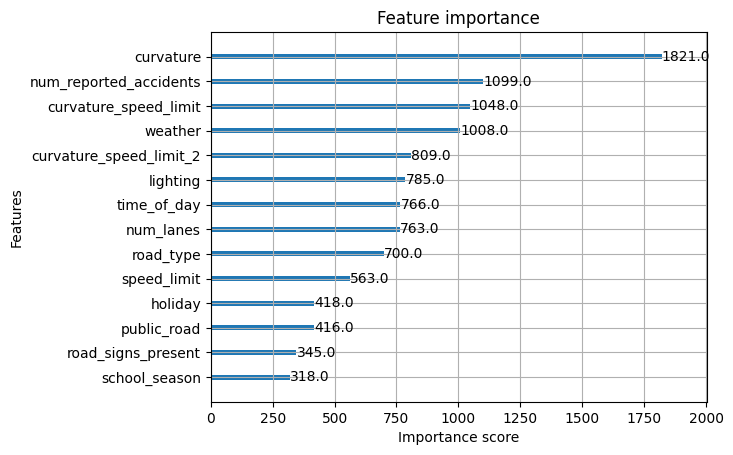

In [21]:
xgb.plot_importance(best_reg)

In [22]:
import joblib
import json

with open('models/xgb_optuna_best_params.json', 'w') as f:
    json.dump(study.best_params, f, indent=4)
joblib.dump(best_reg, 'best_xgb_optuna_model.pkl')

# with open('models/xgb_optuna_best_params.json') as param_file:
#    best_xgb_optuna_param = json.load(param_file)
# best_reg = joblib.load('best_xgb_model.pkl')

['best_xgb_optuna_model.pkl']

In [23]:
print(f'Test Score: {rmse(y_test, best_reg.predict(full_preprocessor.transform(X_test)))}')

Test Score: 0.0565083712301277


# Submit Prediction

In [24]:
full_test_csv = pd.read_csv('datasets/test.csv', index_col=0)
full_test_encoded = full_preprocessor.transform(full_test_csv)
full_test_encoded.head()

,road_type,weather,lighting,time_of_day,road_signs_present,public_road,holiday,school_season,num_lanes,curvature,speed_limit,num_reported_accidents,curvature_speed_limit,curvature_speed_limit_2
id,,,,,,,,,,,,,,
517754,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,2,0.34,45,1,15.30,688.50
517755,2.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,3,0.04,45,0,1.80,81.00
517756,2.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,2,0.59,35,1,20.65,722.75
517757,1.0,2.0,2.0,1.0,0.0,0.0,0.0,0.0,4,0.95,35,2,33.25,1163.75
517758,0.0,0.0,2.0,2.0,1.0,0.0,0.0,1.0,2,0.86,35,3,30.10,1053.50


## Best XGB Classifier

In [25]:
y_pred = best_reg.predict(full_test_encoded)

In [26]:
submission = pd.read_csv('datasets/sample_submission.csv', index_col=0)
print(submission.head())
submission[TARGET] = y_pred.round(3)
print('\n')
print(submission.head())
submission.to_csv('datasets/submission_XGB_Optuna.csv')
print('Result saved successfully!')

        accident_risk
id                   
517754          0.352
517755          0.352
517756          0.352
517757          0.352
517758          0.352


        accident_risk
id                   
517754          0.291
517755          0.120
517756          0.184
517757          0.315
517758          0.397
Result saved successfully!


Public Score: 0.05576